# Análisis Exploratorio de Datos (EDA): Incidentes de Focos de Calor en Europa (MODIS)

## **1. Configuración del entorno y carga de datos**

In [1]:
import os
import glob
import io
import time
from io import StringIO
from pathlib import Path as SystemPath
import nbformat
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import openpyxl
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.path import Path
import seaborn as sns
import contextily as ctx
import geodatasets
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import streamlit as st
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    IsolationForest, 
    RandomForestClassifier, 
    RandomForestRegressor, 
    HistGradientBoostingClassifier
)
from sklearn.linear_model import Ridge
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)
import requests
from io import StringIO
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.cluster import HDBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib





c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Configuración de rutas
DB_NAME = r"Base-de-datos\pirovigia.db"

OUTPUT_DIR = os.path.join("data", "extraccion_basedatos")
CSV_NAME = os.path.join(OUTPUT_DIR, "detecciones_unificadas.csv")


def obtener_datos_unificados():
    # Aseguramos que la carpeta de destino exista
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Conexión a la base de datos (solo lectura)
    conn = sqlite3.connect(DB_NAME)

    # 2. Leemos la tabla 'detecciones'
    query_detecciones = """
        SELECT 
            latitude, longitude, brightness, scan, track, acq_date, acq_time,
            satellite, instrument, CAST(confidence AS TEXT) AS confidence,
            version, bright_t31, frp, CAST(daynight AS TEXT) AS daynight, 
            type, 'detecciones' AS origen
        FROM detecciones
    """
    df_detecciones = pd.read_sql_query(query_detecciones, conn)

    # 3. Leemos la tabla 'detecciones_tiemporeal'
    query_tiemporeal = """
        SELECT 
            latitude, longitude, bright_ti4 AS brightness, scan, track,
            SUBSTR(CAST(acq_date AS TEXT), 1, 10) AS acq_date,
            COALESCE(
                acq_time, 
                CAST(REPLACE(SUBSTR(CAST(acq_date AS TEXT), 12, 5), ':', '') AS INTEGER)
            ) AS acq_time,
            satellite, instrument, CAST(confidence AS TEXT) AS confidence,
            version, bright_ti5 AS bright_t31, frp,
            CASE UPPER(TRIM(daynight))
                WHEN 'N' THEN 'false'
                WHEN 'D' THEN 'true'
                ELSE CAST(daynight AS TEXT)
            END AS daynight,
            CASE LOWER(TRIM(COALESCE(origen_calculado, '')))
                WHEN 'incendio forestal' THEN 0
                WHEN 'zona industrial' THEN 2
                ELSE 1
            END AS type,
            'detecciones_tiemporeal' AS origen
        FROM detecciones_tiemporeal
    """
    df_tiemporeal = pd.read_sql_query(query_tiemporeal, conn)

    # Cerramos la conexión a la BD
    conn.close()

    # 4. Unificamos ambos DataFrames en memoria
    df_unificado = pd.concat([df_detecciones, df_tiemporeal], ignore_index=True)

    # 5. Corrección de fechas en 'detecciones' (Mes/Día/Año -> Año-Mes-Día)
    mask = df_unificado["origen"] == "detecciones"

    # Convierte las fechas interpretando que el origen está como Mes/Día/Año (o Mes-Día-Año)
    # y lo transforma a AÑO-MES-DÍA (%Y-%m-%d)
    fechas_convertidas = pd.to_datetime(
        df_unificado.loc[mask, "acq_date"], format="mixed", dayfirst=False
    )
    df_unificado.loc[mask, "acq_date"] = fechas_convertidas.dt.strftime(
        "%Y-%m-%d"
    )

    # 6. Guardamos directamente a CSV en la carpeta solicitada
    df_unificado.to_csv(CSV_NAME, index=False, encoding="utf-8")

    print(f"✅ Unificación y exportación completadas con éxito.")
    print(f"📊 Registros totales exportados: {len(df_unificado)}")
    print(f"📁 Archivo generado en: '{CSV_NAME}'")

    return df_unificado


# --- EJECUCIÓN DEL SCRIPT ---
if __name__ == "__main__":
    unificada = obtener_datos_unificados()

    print("\n--- Vista previa de los datos unificados ---")
    print(unificada[["acq_date", "origen"]].head(10))

✅ Unificación y exportación completadas con éxito.
📊 Registros totales exportados: 128688
📁 Archivo generado en: 'data\extraccion_basedatos\detecciones_unificadas.csv'

--- Vista previa de los datos unificados ---
     acq_date       origen
0  2020-01-01  detecciones
1  2020-01-01  detecciones
2  2020-01-01  detecciones
3  2020-01-01  detecciones
4  2020-01-01  detecciones
5  2020-01-01  detecciones
6  2020-01-01  detecciones
7  2020-01-01  detecciones
8  2020-01-01  detecciones
9  2020-01-01  detecciones


## **2. Limpieza**

In [3]:
df = pd.read_csv("data/extraccion_basedatos/detecciones_unificadas.csv")

C:\Users\felix\AppData\Local\Temp\ipykernel_16648\3178363816.py:1: DtypeWarning: Columns (0: confidence, 1: version) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/extraccion_basedatos/detecciones_unificadas.csv")


In [4]:
# Diagnóstico de calidad de datos
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores No Nulos': df.count(),
    'Valores Nulos': df.isnull().sum(),
    '% de Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})

print(" 1. INFO DE DATOS Y CALIDAD:")
display(info_df)  # Usamos display para mostrar ambas tablas de forma interactiva

print("\n 2. VISTA PREVIA DEL DATASET (Primeros registros):")
df.head()

 1. INFO DE DATOS Y CALIDAD:


,Tipo de Dato,Valores No Nulos,Valores Nulos,% de Nulos
latitude,float64,128688,0,0.0
longitude,float64,128688,0,0.0
brightness,float64,128688,0,0.0
scan,float64,128688,0,0.0
track,float64,128688,0,0.0
acq_date,str,128688,0,0.0
acq_time,int64,128688,0,0.0
satellite,str,128688,0,0.0
instrument,str,128688,0,0.0
confidence,object,128688,0,0.0



 2. VISTA PREVIA DEL DATASET (Primeros registros):


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,origen
0,43.16465,-6.50024,337.81,0.38,0.59,2020-01-01,133,N20,VIIRS,False,2,275.14,3.73,False,0,detecciones
1,41.19420,-4.43953,298.58,0.57,0.52,2020-01-01,133,N20,VIIRS,False,2,269.06,1.23,False,0,detecciones
2,43.17036,-6.38798,329.74,0.38,0.59,2020-01-01,133,N20,VIIRS,False,2,277.59,2.24,False,0,detecciones
3,41.19474,-4.43869,298.47,0.57,0.52,2020-01-01,133,N20,VIIRS,False,2,269.00,1.28,False,0,detecciones
4,41.31337,1.66073,313.49,0.45,0.39,2020-01-01,133,N20,VIIRS,False,2,278.19,2.27,False,2,detecciones


In [5]:
# 1. Asegurar que las columnas sean de tipo numérico (float/int)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')

# 2. Filtrar coordenadas (nota: between elimina nulos automáticamente)
df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180))
]

# 3. Filtrar confianza (los NaN generados por textos no numéricos se descartarán aquí)
df = df[df['confidence'].between(0, 100)]


In [6]:
# 1. Asegurar que las variables categóricas sean de tipo texto/cadena primero
cols_categoricas = ['satellite', 'instrument', 'daynight', 'pais', 'type']

for col in cols_categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().astype('category')

# 2. Asegurar que las variables continuas sean numéricas antes de redondear
cols_numericas = ['brightness', 'bright_t31', 'frp']

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Redondeo para estandarizar y limpiar flotantes
df['brightness'] = df['brightness'].round(2)
df['bright_t31'] = df['bright_t31'].round(2)
df['frp'] = df['frp'].round(2)

# Comprobación del ahorro de memoria
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 108721 entries, 0 to 128687
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   latitude    108721 non-null  float64 
 1   longitude   108721 non-null  float64 
 2   brightness  108721 non-null  float64 
 3   scan        108721 non-null  float64 
 4   track       108721 non-null  float64 
 5   acq_date    108721 non-null  str     
 6   acq_time    108721 non-null  int64   
 7   satellite   108721 non-null  category
 8   instrument  108721 non-null  category
 9   confidence  108721 non-null  float64 
 10  version     108721 non-null  object  
 11  bright_t31  108721 non-null  float64 
 12  frp         108721 non-null  float64 
 13  daynight    108721 non-null  category
 14  type        108721 non-null  category
 15  origen      108721 non-null  str     
dtypes: category(4), float64(8), int64(1), object(1), str(2)
memory usage: 16.6 MB


In [7]:
# 1. Mapeo con claves como enteros y como cadenas por seguridad
diccionario_tipos = {
    0: 'Incendio forestal/vegetación',
    1: 'Volcán',
    2: 'Industria/Foco estático',
    3: 'Otros/Fuera de rango'
}

# 2. Convertir a numérico (int/float) antes de mapear
# Usamos int64 descompuesto o simplemente mapeamos convirtiendo a entero
df['type'] = pd.to_numeric(df['type'], errors='coerce')

# 3. Aplicar el mapeo
df['type'] = df['type'].map(diccionario_tipos)

# 4. Asignar categoría (los valores no mapeados se rellenan opcionalmente)
df['type'] = df['type'].fillna('Otros/Fuera de rango').astype('category')

# 5. Verificar el cambio
print(df['type'].value_counts(dropna=False))

type
Incendio forestal/vegetación    88517
Industria/Foco estático         19955
Otros/Fuera de rango              245
Volcán                              4
Name: count, dtype: int64


In [8]:
# Crear la carpeta 'data'
os.makedirs('data', exist_ok=True)

# Modificar la ruta de salida para incluir la carpeta
archivo_salida = 'data/modis_2024_unificado_limpio.csv'

# Guardar los datos limpios dentro de la carpeta (Cambiado df_clean por df)
df.to_csv(archivo_salida, index=False)

print(f"Dimensiones finales tras la limpieza: {df.shape}")
print(f"¡Base de datos limpia guardada como '{archivo_salida}'!")

df_clean = pd.read_csv(r'data/modis_2024_unificado_limpio.csv')
df_clean.head()



Dimensiones finales tras la limpieza: (108721, 16)
¡Base de datos limpia guardada como 'data/modis_2024_unificado_limpio.csv'!


C:\Users\felix\AppData\Local\Temp\ipykernel_16648\1568923201.py:13: DtypeWarning: Columns (0: version) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv(r'data/modis_2024_unificado_limpio.csv')


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,origen
0,43.16465,-6.50024,337.81,0.38,0.59,2020-01-01,133,N20,VIIRS,0.0,2,275.14,3.73,False,Incendio forestal/vegetación,detecciones
1,41.19420,-4.43953,298.58,0.57,0.52,2020-01-01,133,N20,VIIRS,0.0,2,269.06,1.23,False,Incendio forestal/vegetación,detecciones
2,43.17036,-6.38798,329.74,0.38,0.59,2020-01-01,133,N20,VIIRS,0.0,2,277.59,2.24,False,Incendio forestal/vegetación,detecciones
3,41.19474,-4.43869,298.47,0.57,0.52,2020-01-01,133,N20,VIIRS,0.0,2,269.00,1.28,False,Incendio forestal/vegetación,detecciones
4,41.31337,1.66073,313.49,0.45,0.39,2020-01-01,133,N20,VIIRS,0.0,2,278.19,2.27,False,Industria/Foco estático,detecciones


## **3. Análisis de calidad de los datos y filtro de ruido**

Distribución original de confianza:
count    108721.000000
mean          4.790703
std          14.716871
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          50.000000
Name: confidence, dtype: float64
Cantidad de registros considerados ruido: 98304 (90.42%) )

Distribución de tipos de focos en el ruido:
type
Incendio forestal/vegetación    78221
Industria/Foco estático         19834
Otros/Fuera de rango              245
Volcán                              4
Name: count, dtype: int64


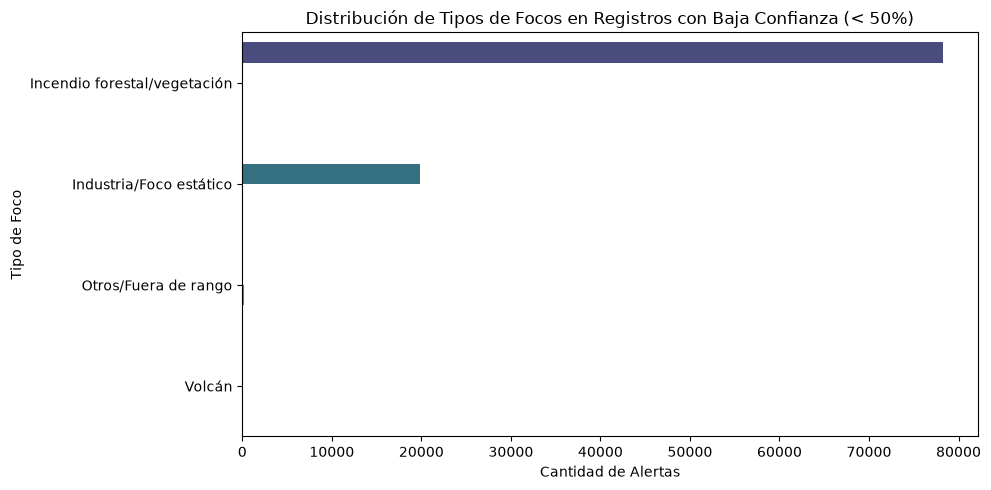


Registros originales: 108721
Registros tras eliminar ruido: 10417
Falsos positivos/Ruido eliminado: 98304 alertas.


In [9]:
# Evaluación estadística de la métrica de fiabilidad antes de la depuración
# Analizar la distribución de la calidad antes de limpiar
print("Distribución original de confianza:")
print(df_clean['confidence'].describe())

# Creamos un subconjunto de datos sin ruido, eliminando alertas con confianza baja (< 50%)
df_ruido = df[df['confidence'] < 50]
print(f"Cantidad de registros considerados ruido: {df_ruido.shape[0]} ({(df_ruido.shape[0] / len(df_clean) * 100):.2f}%) )")

# Identificación y segmentación de registros de ruido: análisis de tipos de focos
print("\nDistribución de tipos de focos en el ruido:")
print(df_ruido['type'].value_counts())

# Visualización de la distribución del ruido por tipo de foco
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_ruido, 
    y='type', 
    order=df_ruido['type'].value_counts().index,
    hue='type',
    palette='viridis',
    legend=False
)
plt.title('Distribución de Tipos de Focos en Registros con Baja Confianza (< 50%)')
plt.xlabel('Cantidad de Alertas')
plt.ylabel('Tipo de Foco')
plt.tight_layout()
plt.show()

# Aplicar el filtro de ruido: Quedarnos solo con alertas de confianza Media y Alta (>= 50%)
df_sin_ruido = df_clean[df_clean['confidence'] >= 50].copy()

print(f"\nRegistros originales: {len(df_clean)}")
print(f"Registros tras eliminar ruido: {len(df_sin_ruido)}")
print(f"Falsos positivos/Ruido eliminado: {len(df_clean) - len(df_sin_ruido)} alertas.")

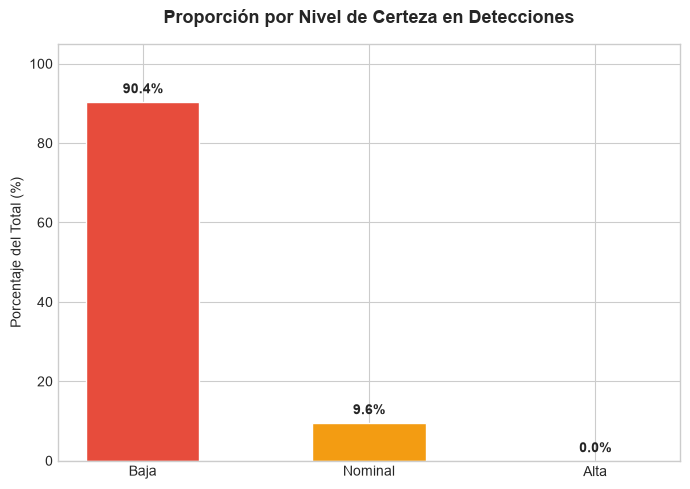

=== Resumen de Registros por Calidad ===
Nivel_Calidad
Baja (<49%)         98304
Nominal (50-79%)    10417
Name: count, dtype: int64


In [10]:
# --- 1. Clasificación por niveles de certeza ---
def asignar_nivel(val):
    if val < 50: 
        return 'Baja (<49%)'
    elif val < 80: 
        return 'Nominal (50-79%)'
    else: 
        return 'Alta (≥80%)'

df['Nivel_Calidad'] = df['confidence'].apply(asignar_nivel)

# --- 2. Gráfica Única: Proporción % por Nivel ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7, 5))

# Paleta de colores
paleta = {
    'Baja (<49%)': '#e74c3c',       # Rojo
    'Nominal (50-79%)': '#f39c12',  # Naranja
    'Alta (≥80%)': '#2ecc71'        # Verde
}

# Cálculo de porcentajes
conteo = df['Nivel_Calidad'].value_counts(normalize=True) * 100
orden = ['Baja (<49%)', 'Nominal (50-79%)', 'Alta (≥80%)']
conteo = conteo.reindex(orden).fillna(0)

# Construcción de barras
bars = ax.bar(
    ['Baja', 'Nominal', 'Alta'], 
    conteo.values, 
    color=[paleta[k] for k in orden], 
    width=0.5, 
    edgecolor='white'
)

# Estilo de la gráfica
ax.set_title('Proporción por Nivel de Certeza en Detecciones', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
ax.set_ylim(0, 105)

# Etiquetas sobre cada barra
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

# --- 3. Resumen cuantitativo ---
print("=== Resumen de Registros por Calidad ===")
print(df['Nivel_Calidad'].value_counts())

--- Inspección de la columna 'confidence' ---
Tipo de dato: float64
Valores mínimos y máximos: 0.0 a 50.0


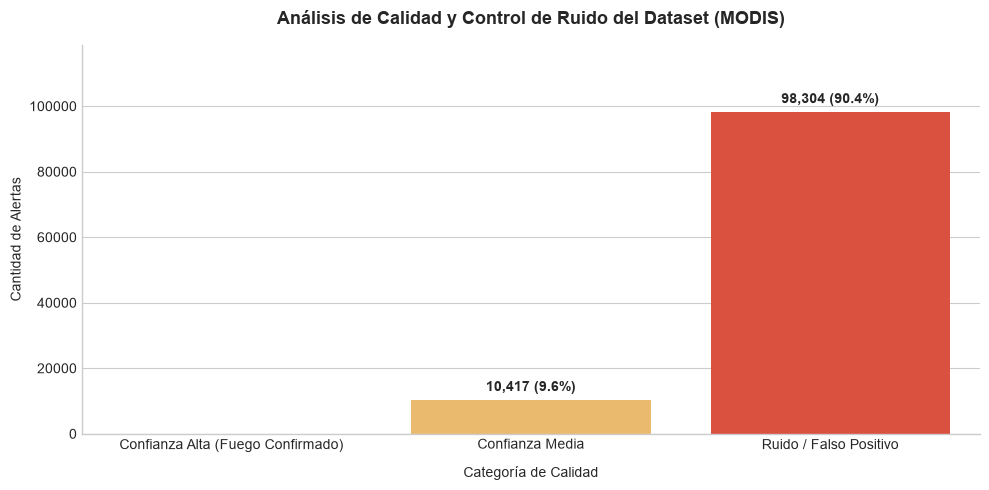

=== Resumen de Calidad ===
calidad_alerta
Ruido / Falso Positivo    98304
Confianza Media           10417
Name: count, dtype: int64


In [11]:
# 1. Inspección previa en consola para verificar la escala
print("--- Inspección de la columna 'confidence' ---")
print("Tipo de dato:", df['confidence'].dtype)
print("Valores mínimos y máximos:", df['confidence'].min(), "a", df['confidence'].max())

# 2. Corrección automática si la confianza está en decimales (0.0 a 1.0)
if df['confidence'].max() <= 1.0:
    df['confidence_pct'] = df['confidence'] * 100
else:
    df['confidence_pct'] = pd.to_numeric(df['confidence'], errors='coerce')

# 3. Clasificación según estándar MODIS
def clasificar_calidad(conf):
    if pd.isna(conf):
        return 'Sin Dato'
    elif conf < 30:
        return 'Ruido / Falso Positivo'
    elif conf < 80:
        return 'Confianza Media'
    else:
        return 'Confianza Alta (Fuego Confirmado)'

df['calidad_alerta'] = df['confidence_pct'].apply(clasificar_calidad)

# 4. Generación del gráfico
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 5))

orden_categorias = ['Confianza Alta (Fuego Confirmado)', 'Confianza Media', 'Ruido / Falso Positivo']

ax = sns.countplot(
    data=df, 
    x='calidad_alerta', 
    hue='calidad_alerta',
    palette='YlOrRd_r', 
    order=orden_categorias,
    legend=False
)

plt.title('Análisis de Calidad y Control de Ruido del Dataset (MODIS)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Categoría de Calidad', fontsize=10, labelpad=10)
plt.ylabel('Cantidad de Alertas', fontsize=10)

total_registros = len(df)

for bar in ax.patches:
    altura = bar.get_height()
    if altura > 0:
        porcentaje = (altura / total_registros) * 100
        ax.annotate(
            f'{int(altura):,} ({porcentaje:.1f}%)',
            xy=(bar.get_x() + bar.get_width() / 2, altura),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

# 5. Resumen cuantitativo
print("=== Resumen de Calidad ===")
print(df['calidad_alerta'].value_counts())

## **4. Análisis temporal y evaluación de focos de calor**

In [12]:
def plot_temporal_evolution(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Usamos acq_date que es como se llama en tu tabla unificada
    fechas_correctas = pd.to_datetime(dataframe['acq_date'], errors='coerce')
    
    # Agrupamos usando 'fechas_correctas'
    focos_por_mes = dataframe.groupby(fechas_correctas.dt.to_period('M')).size()
    focos_por_mes.index = focos_por_mes.index.to_timestamp()
    
    # Gráfico y sombreado
    ax.plot(focos_por_mes.index, focos_por_mes.values, 
            marker='o', markersize=8, color='#dc2626', linewidth=3)
    
    ax.fill_between(focos_por_mes.index, focos_por_mes.values, 
                    color='#fee2e2', alpha=0.5) 
    
    # Formato de fechas en el eje X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    
    # Etiquetas
    ax.set_title('📅 Evolución Mensual de Alertas Térmicas', 
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a')
    ax.set_xlabel('Periodo Mensual', fontsize=11, fontweight='semibold', color='#475569')
    ax.set_ylabel('Frecuencia de Alertas', fontsize=11, fontweight='semibold', color='#475569')
    
    ax.grid(True, linestyle=':', alpha=0.6, color='#94a3b8')
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    return fig

findfont: Failed to find font weight semibold, now using 700.
C:\Users\felix\AppData\Local\Temp\ipykernel_16648\2686705914.py:82: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


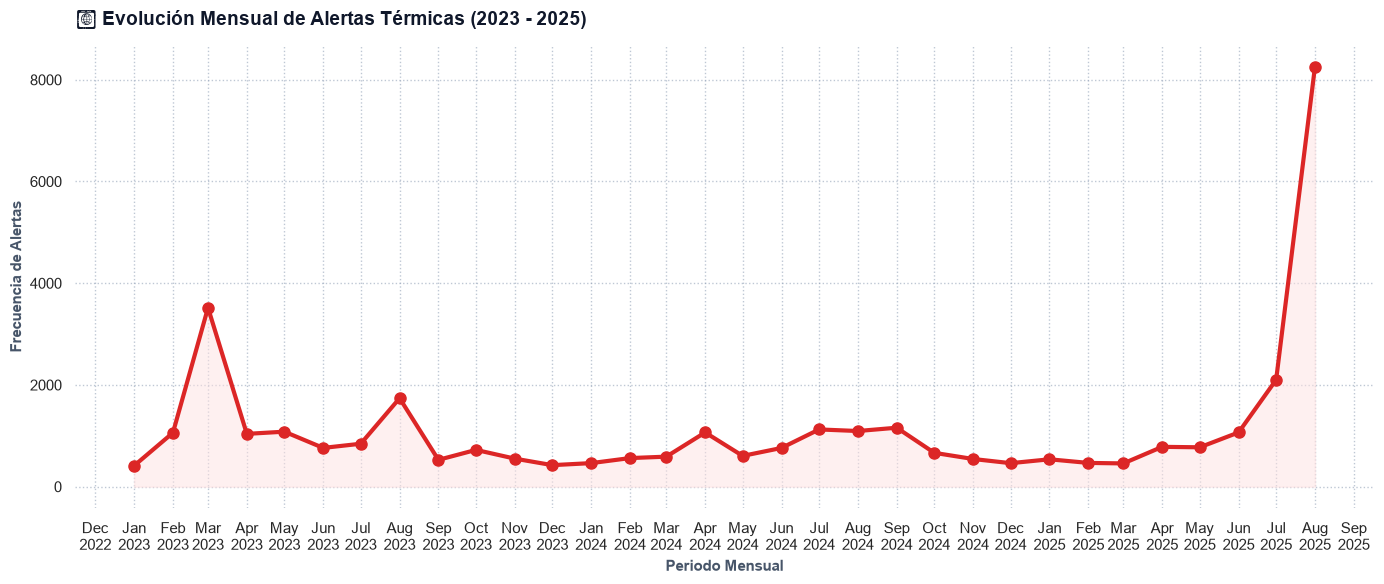

In [13]:
# Estética Jupyter
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# 1. PREPROCESAMIENTO: Crear la columna 'acq_datetime'
df_clean["acq_time_str"] = (
    df_clean["acq_time"].fillna(0).astype(int).astype(str).str.zfill(4)
)

df_clean["acq_datetime"] = pd.to_datetime(
    df_clean["acq_date"].astype(str)
    + " "
    + df_clean["acq_time_str"].str[:2]
    + ":"
    + df_clean["acq_time_str"].str[2:],
    errors="coerce",
)


# 2. FUNCIÓN DE GRÁFICO: Filtrada para 2025 - 2026
def plot_temporal_evolution_25_26(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))

    # Filtrar el DataFrame directamente por el rango de fechas (2023 a 2025)
    mask = (dataframe["acq_datetime"] >= "2023-01-01") & (
        dataframe["acq_datetime"] <= "2025-12-31"
    )
    df_filtered = dataframe[mask]

    if df_filtered.empty:
        print(
            "⚠️ No hay registros de focos de calor entre 2023 y 2025 en este DataFrame."
        )
        return fig

    # Agrupamos por año-mes usando la nueva columna acq_datetime
    focos_por_mes = df_filtered.groupby(
        df_filtered["acq_datetime"].dt.to_period("M")
    ).size()
    focos_por_mes.index = focos_por_mes.index.to_timestamp()

    # Trazado de la línea principal y sombreado inferior
    ax.plot(
        focos_por_mes.index,
        focos_por_mes.values,
        marker="o",
        markersize=8,
        color="#dc2626",
        linewidth=3,
    )

    ax.fill_between(
        focos_por_mes.index, focos_por_mes.values, color="#fee2e2", alpha=0.5
    )

    # Configuración del eje X: Marca un tick por cada mes del periodo 2023-2025
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

    # Personalización visual
    ax.set_title(
        "📅 Evolución Mensual de Alertas Térmicas (2023 - 2025)",
        fontsize=14,
        fontweight="bold",
        pad=15,
        loc="left",
        color="#0f172a",
    )
    ax.set_xlabel(
        "Periodo Mensual", fontsize=11, fontweight="semibold", color="#475569"
    )
    ax.set_ylabel(
        "Frecuencia de Alertas",
        fontsize=11,
        fontweight="semibold",
        color="#475569",
    )

    ax.grid(True, linestyle=":", alpha=0.6, color="#94a3b8")
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    return fig


# 3. EJECUCIÓN
fig = plot_temporal_evolution_25_26(df_clean)
plt.show()


📊 --- Comportamiento Agregado por Criterio Temporal ---
 mes_num mes_nombre trimestre  total_detecciones  frp_promedio  frp_maximo  confianza_media
       1        Ene        Q1               4000      4.519565      214.40         0.000000
       2        Feb        Q1               5314      5.109814      379.50         0.000000
       3        Mar        Q1               7031      6.633945      280.03         0.000000
       4        Abr        Q2               4659      5.346046      326.20         0.000000
       5        May        Q2               4945      7.938823      939.41         0.000000
       6        Jun        Q2               7047     10.376828      833.60         0.000000
       7        Jul        Q3              24702     15.749014     1418.19        21.085337
       8        Ago        Q3              20563     23.601700     2313.87         0.000000
       9        Sep        Q3               8022     17.689703     1589.99         0.000000
      10        Oct    

C:\Users\felix\AppData\Local\Temp\ipykernel_16648\503280286.py:74: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


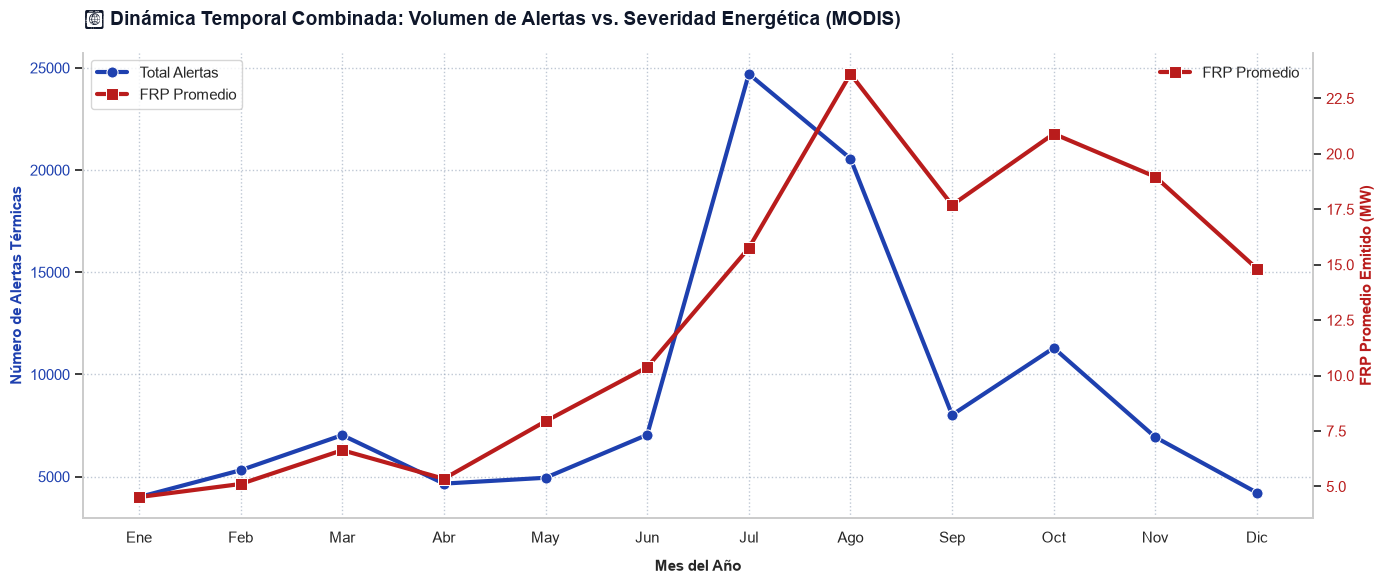

In [14]:
# Tendencia temporal: análisis avanzado por mes y trimestre
# Configurar estética nativa de Jupyter / Colab
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def generar_analisis_temporal_avanzado(dataframe):
    # Clonamos para no alterar el dataframe original
    df_temp = dataframe.copy()
    
    # Parsing estricto garantizado
    df_temp['acq_date'] = pd.to_datetime(df_temp['acq_date'], errors='coerce')
    
    # Crear características temporales legibles
    df_temp['mes_num'] = df_temp['acq_date'].dt.month
    
    # Diccionario para forzar los nombres de los meses en español (evita problemas de locale en Colab)
    meses_es = {
        1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
    }
    df_temp['mes_nombre'] = df_temp['mes_num'].map(meses_es)
    df_temp['trimestre'] = 'Q' + df_temp['acq_date'].dt.quarter.astype(str)
    
    # Agrupación temporal corregida
    tabla_temporal = df_temp.groupby(['mes_num', 'mes_nombre', 'trimestre']).agg(
        total_detecciones=('frp', 'count'),
        frp_promedio=('frp', 'mean'),
        frp_maximo=('frp', 'max'),
        confianza_media=('confidence', 'mean')
    ).reset_index().sort_values('mes_num')
    
    print("\n📊 --- Comportamiento Agregado por Criterio Temporal ---")
    print(tabla_temporal.to_string(index=False))
    
    # Construcción del Gráfico de Líneas Multieje Profesional
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Primer Eje (Izquierdo): Volumetría de alertas
    color_alertas = '#1e40af' # Azul oscuro técnico
    ax1.set_xlabel('Mes del Año', fontsize=11, fontweight='semibold', labelpad=10)
    ax1.set_ylabel('Número de Alertas Térmicas', color=color_alertas, fontsize=11, fontweight='semibold')
    
    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='total_detecciones', 
        marker='o', markersize=8, color=color_alertas, ax=ax1, linewidth=3, label='Total Alertas'
    )
    ax1.tick_params(axis='y', labelcolor=color_alertas)
    ax1.grid(True, linestyle=':', alpha=0.6, color='#94a3b8') # Rejilla sutil de fondo
    
    # Segundo Eje (Derecho): Severidad Energética (FRP)
    ax2 = ax1.twinx()
    color_frp = '#b91c1c' # Rojo fuego premium
    ax2.set_ylabel('FRP Promedio Emitido (MW)', color=color_frp, fontsize=11, fontweight='semibold')
    
    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='frp_promedio', 
        marker='s', markersize=8, color=color_frp, ax=ax2, linewidth=3, label='FRP Promedio'
    )
    ax2.tick_params(axis='y', labelcolor=color_frp)
    ax2.grid(False) # Evitamos que las rejillas se crucen
    
    # Unificar leyendas de ambos ejes en una sola esquina limpia
    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', frameon=True)
    
    # Títulos y limpieza de bordes
    plt.title('📅 Dinámica Temporal Combinada: Volumen de Alertas vs. Severidad Energética (MODIS)', 
              fontsize=14, fontweight='bold', color='#0f172a', pad=20, loc='left')
    
    sns.despine(ax=ax1, top=True, left=False, right=False)
    sns.despine(ax=ax2, top=True, left=False, right=False)
    
    plt.tight_layout()
    return fig, tabla_temporal

# Lanzar proceso usando tu DataFrame df_clean
fig, tabla_resumen = generar_analisis_temporal_avanzado(df_clean)
plt.show()

c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


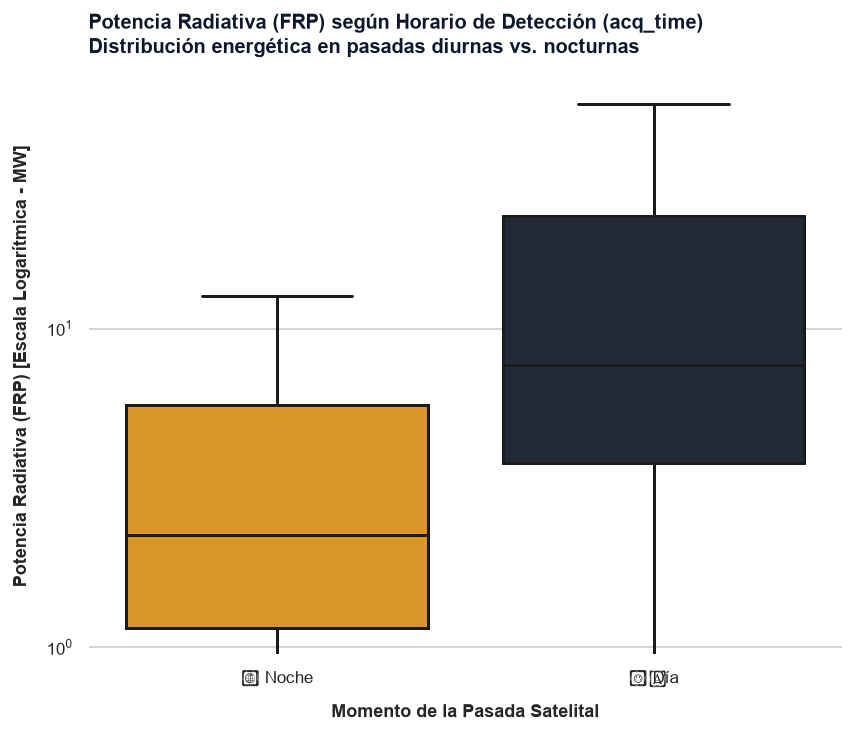

In [15]:
# Configurar estética
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 120

def plot_fire_severity_day_night(dataframe):
    # Crear copia interna
    df_temp = dataframe.copy()
    
    # 1. Extraer la hora a partir de 'acq_time' y calcular 'daynight' si no existe
    if 'acq_time' in df_temp.columns:
        # Convertimos a string zfill(4) para asegurar 4 dígitos (ej. 130 -> "0130")
        acq_str = df_temp['acq_time'].astype(str).str.split('.').str[0].str.zfill(4)
        horas = acq_str.str[:2].astype(int)
        
        # Clasificamos: Día (06:00 a 18:00) vs Noche (Resto)
        df_temp['daynight'] = horas.apply(lambda h: 'D' if 6 <= h < 18 else 'N')
    elif 'daynight' not in df_temp.columns:
        raise ValueError("El DataFrame no contiene las columnas 'acq_time' ni 'daynight'")

    # 2. Configurar la figura
    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")

    df_temp['daynight_label'] = df_temp['daynight'].map({'D': '☀️ Día', 'N': '🌙 Noche'})
    
    # Gráfico de caja (Boxplot)
    sns.boxplot(
        ax=ax, 
        data=df_temp, 
        x='daynight_label', 
        y='frp', 
        hue='daynight_label',
        showfliers=False,
        palette=['#f59e0b', '#1e293b'], # Ámbar para día, Oscuro para noche
        linewidth=1.8,
        legend=False
    )
    
    # Escala adaptativa para FRP
    if df_temp['frp'].max() / df_temp['frp'].median() > 15:
        ax.set_yscale('log')
        ax.set_ylabel('Potencia Radiativa (FRP) [Escala Logarítmica - MW]', fontsize=11, fontweight='semibold', labelpad=10)
    else:
        ax.set_ylabel('Potencia Radiativa del Fuego (FRP - MW)', fontsize=11, fontweight='semibold', labelpad=10)

    # Refinamiento de etiquetas y títulos
    ax.set_xlabel('Momento de la Pasada Satelital', fontsize=11, fontweight='semibold', labelpad=10)
    ax.tick_params(labelsize=10)
    
    plt.title('Potencia Radiativa (FRP) según Horario de Detección (acq_time)\n'
              'Distribución energética en pasadas diurnas vs. nocturnas', 
              fontsize=12, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.3)
    
    sns.despine(left=True, bottom=True)
    
    return fig

# Ejecución sobre tu dataframe df
fig_severity = plot_fire_severity_day_night(df)
plt.show()

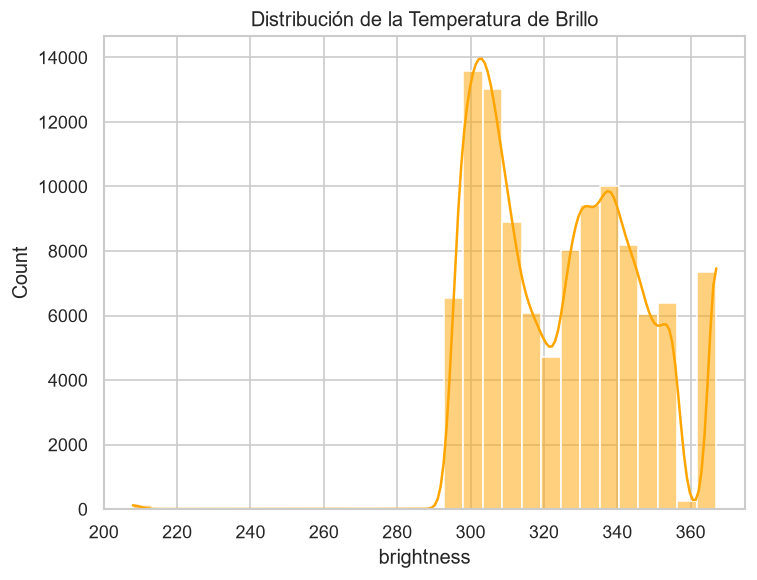

In [16]:
# Análisis de intensidad (distribución de FRP y brillo)
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Histograma de la potencia radiativa del fuego (FRP) o brillo
plt.subplot(1, 2, 1)
sns.histplot(df['brightness'], bins=30, kde=True, color='orange')
plt.title('Distribución de la Temperatura de Brillo')


plt.tight_layout()
plt.show()

## **5. Análisis Geoespacial y mapas de calor**

findfont: Failed to find font weight semibold, now using 700.
C:\Users\felix\AppData\Local\Temp\ipykernel_16648\4075193880.py:54: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


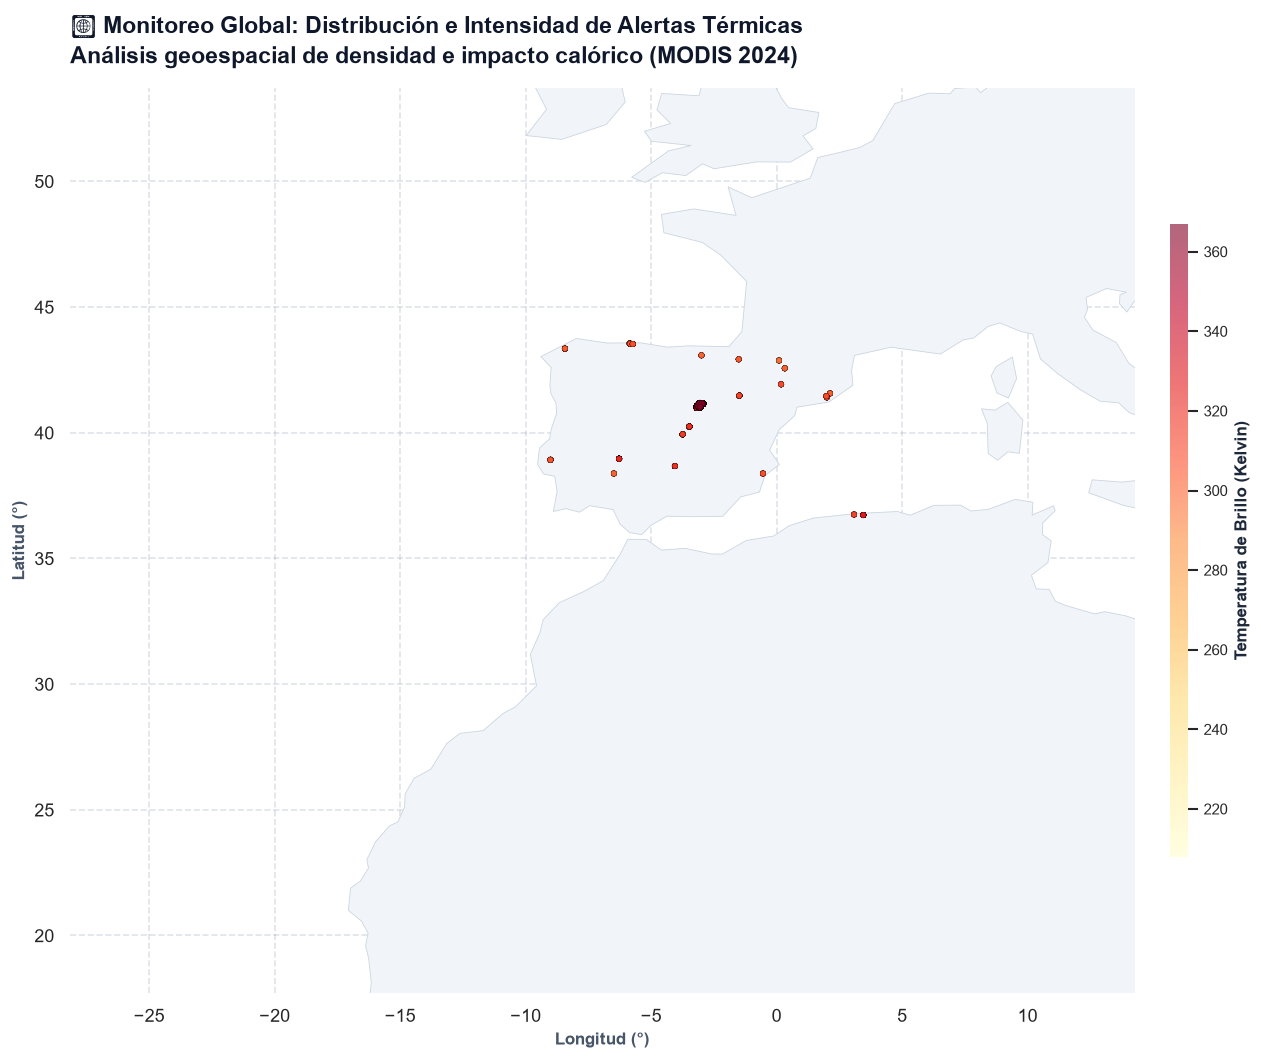

In [17]:
# Visualización de densidad de puntos
# Configurar entorno estético nativo de Jupyter
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 120  

def render_pro_map_with_background(dataframe):
    fig, ax = plt.subplots(figsize=(15, 9))
    
    url_world = geodatasets.get_path("naturalearth.land")
    world = gpd.read_file(url_world)
    world.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.5)
    
    # Pipeline de datos: Evitar Overplotting (Fuegos intensos al frente)
    df_sorted = dataframe.sort_values(by='brightness', ascending=True)
    
    # Escalado semántico para el tamaño basado en confianza
    sizes = (df_sorted['confidence'] / 100) ** 2 * 45

    # Renderizado de las Alertas Térmicas sobre el mapa
    scatter = ax.scatter(
        x=df_sorted['longitude'],
        y=df_sorted['latitude'],
        c=df_sorted['brightness'],
        s=sizes,
        cmap='YlOrRd',       
        alpha=0.6,           
        edgecolors='black',  
        linewidths=0.15,
        zorder=3 # Garantiza que los puntos queden por encima del mapa
    )

    # Estilizado de la barra de color
    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, aspect=35, shrink=0.7)
    cbar.set_label('Temperatura de Brillo (Kelvin)', fontsize=10, fontweight='semibold', color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False) 

    # Límites geográficos 
    ax.set_xlim(dataframe['longitude'].min() - 10, dataframe['longitude'].max() + 10)
    ax.set_ylim(dataframe['latitude'].min() - 10, dataframe['latitude'].max() + 10)

    # Arquitectura de Diseño
    ax.set_title('🔥 Monitoreo Global: Distribución e Intensidad de Alertas Térmicas\n'
                 'Análisis geoespacial de densidad e impacto calórico (MODIS 2024)', 
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a',
                 linespacing=1.4)
    
    ax.set_xlabel('Longitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    ax.set_ylabel('Latitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    
    sns.despine(left=True, bottom=True)
    ax.grid(True, linestyle='--', alpha=0.3, color='#94a3b8')
    
    plt.tight_layout()
    return fig

# Lanzar el gráfico definitivo
fig = render_pro_map_with_background(df)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


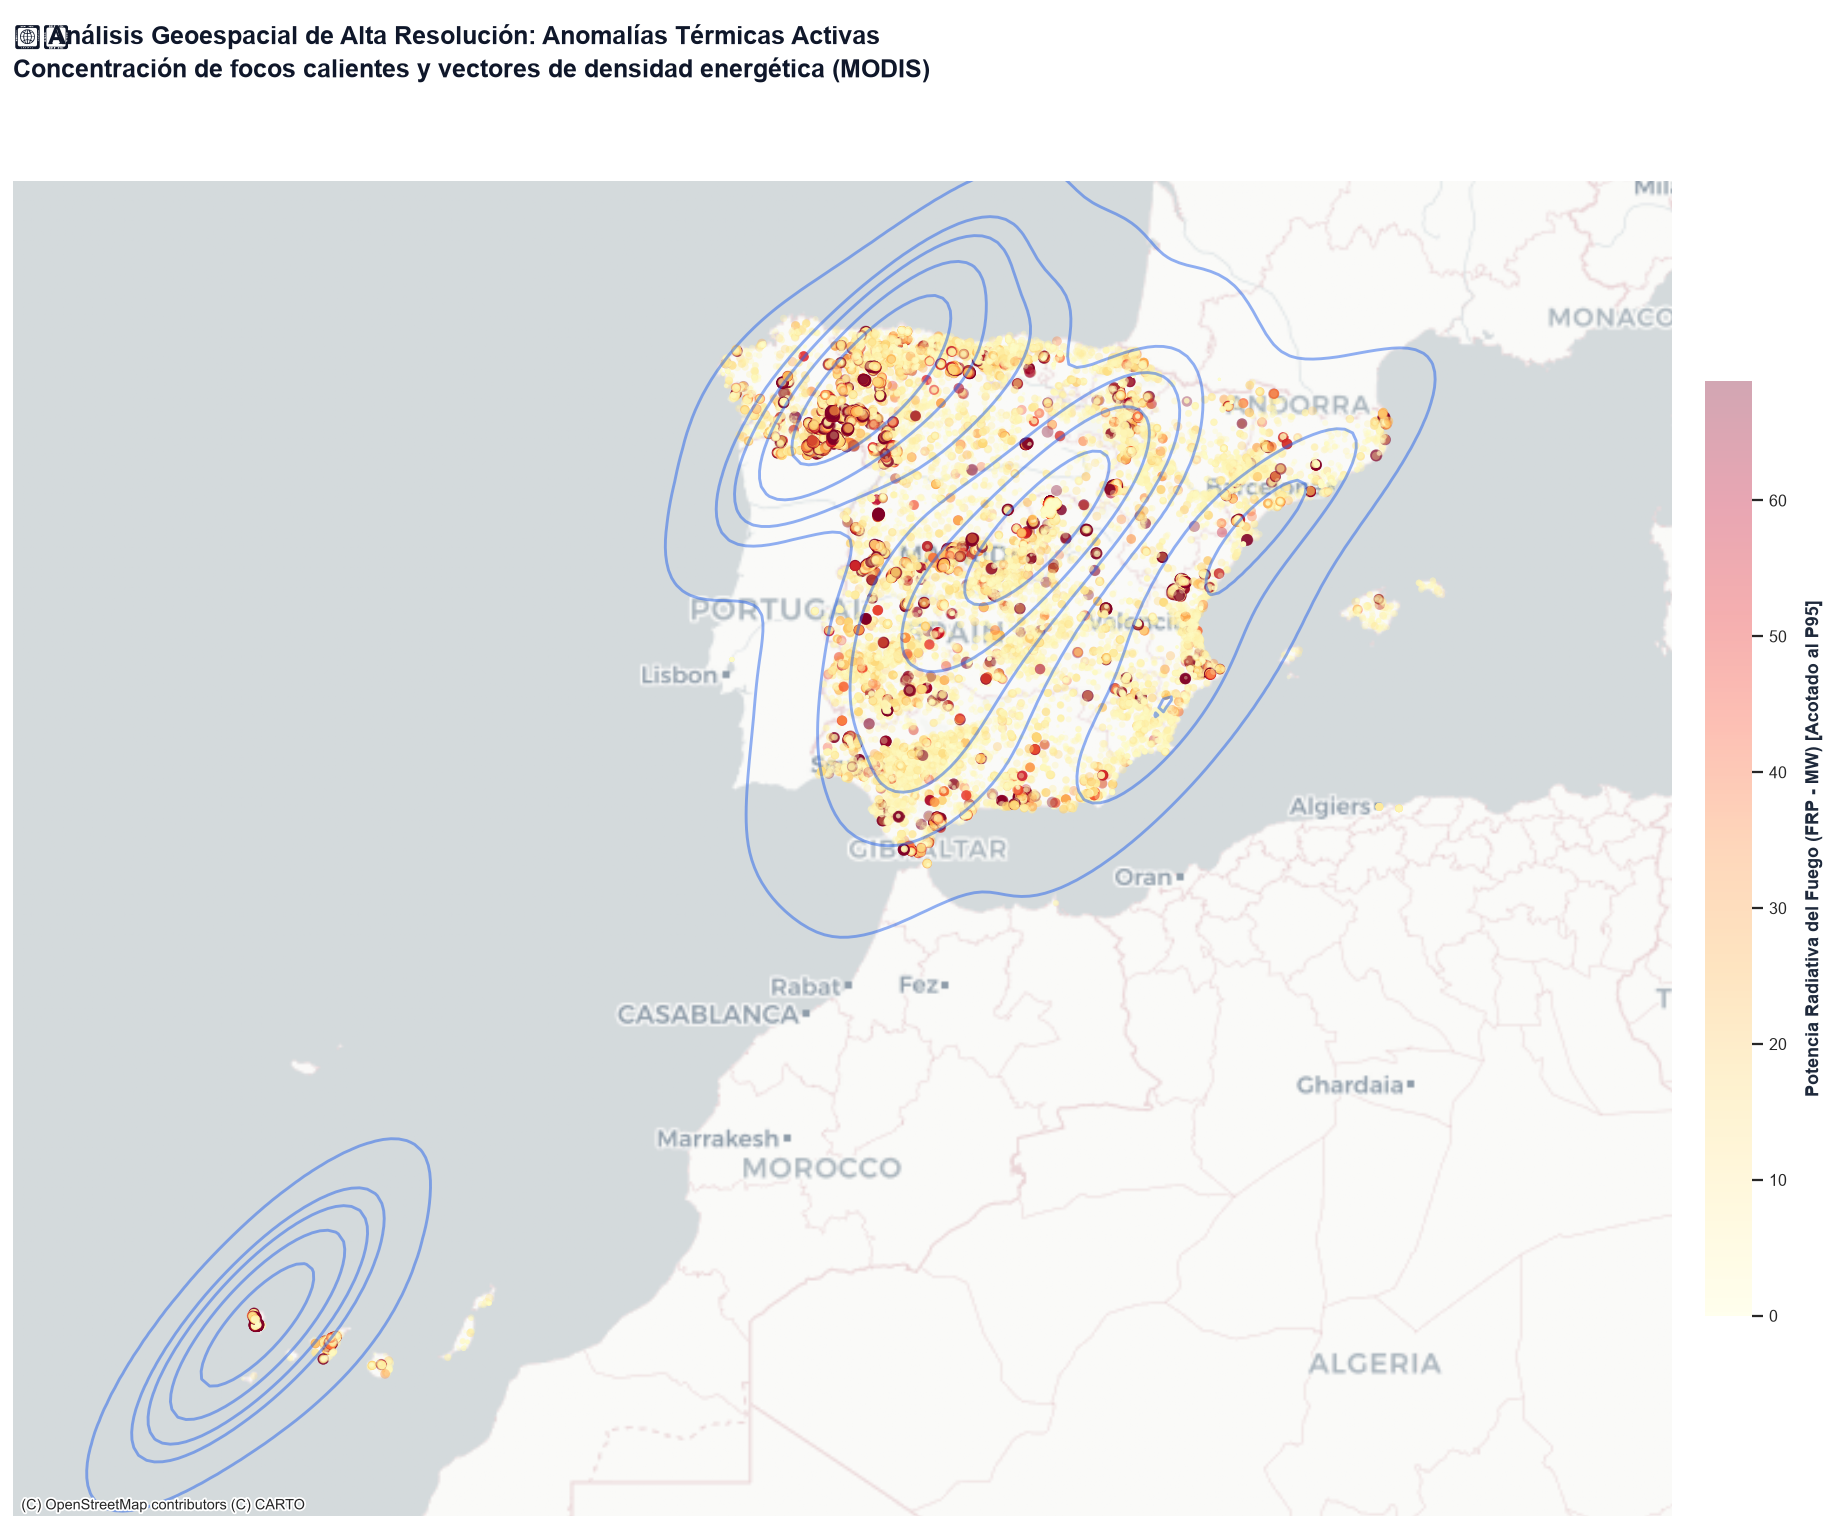

In [18]:
# Distribución geoespacial avanzada con densidad de focos y curvas KDE
# Configurar entorno estético
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 130

def render_mapa_perfecto(dataframe):
    # Convertir el DataFrame a un GeoDataFrame (fijando WGS84 - EPSG:4326)
    gdf = gpd.GeoDataFrame(
        dataframe, 
        geometry=gpd.points_from_xy(dataframe['longitude'], dataframe['latitude']),
        crs="EPSG:4326"
    )
    
    # Transformar automáticamente a Web Mercator (EPSG:3857), que es el que usa CartoDB
    gdf = gdf.to_crs(epsg=3857)
    
    # Extraer las coordenadas ya proyectadas de forma segura
    x = gdf.geometry.x
    y = gdf.geometry.y

    # Calcular dimensiones para el aspecto automático
    ancho_datos = x.max() - x.min() if len(x) > 1 else 150000
    alto_datos = y.max() - y.min() if len(y) > 1 else 150000
    aspect_ratio_datos = alto_datos / ancho_datos

    ancho_fig = 14
    alto_fig = max(6, min(ancho_fig * aspect_ratio_datos, 11))

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig), layout="constrained")
    ax.set_aspect('equal', adjustable='datalim')

    v_max = gdf['frp'].quantile(0.95)

    # Graficar focos de calor
    scatter = ax.scatter(
        x=x, y=y,
        c=gdf['frp'], cmap='YlOrRd',
        s=np.log1p(gdf['frp']) * 8, 
        alpha=0.35, 
        edgecolors='none', 
        norm=plt.Normalize(vmin=0, vmax=v_max),
        zorder=2
    )

    # Curvas KDE con muestreo dinámico
    if len(gdf) > 5000:
        gdf_kde = gdf.sample(5000, random_state=42)
    else:
        gdf_kde = gdf

    sns.kdeplot(
        x=gdf_kde.geometry.x, y=gdf_kde.geometry.y, ax=ax,
        levels=6, color='#2563eb', linewidths=1.6, alpha=0.5,
        zorder=3
    )

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zorder=1)

    # Padding adaptativo
    pad_x = ancho_datos * 0.08
    pad_y = alto_datos * 0.08
    ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
    ax.set_ylim(y.min() - pad_y, y.max() + pad_y)

    # Limpieza y Barra de color
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.7)
    cbar.set_label('Potencia Radiativa del Fuego (FRP - MW) [Acotado al P95]', 
                   fontsize=10, fontweight='semibold', labelpad=10, color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    plt.title('🗺️ Análisis Geoespacial de Alta Resolución: Anomalías Térmicas Activas\n'
              'Concentración de focos calientes y vectores de densidad energética (MODIS)', 
              fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.4)
    
    sns.despine(left=True, bottom=True)
    return fig

# Ejecutar
fig_mapa_premium = render_mapa_perfecto(df_clean)
plt.show()



## **6. Preparación de variables para algoritmos de clustering**

In [19]:
# --- Core libraries ---
import warnings                       # To handle warning messages
import glob                           # For working with file paths/patterns

# --- Data manipulation ---
import pandas as pd                   # Data analysis and manipulation
import numpy as np                    # Numerical computations

# --- Visualization ---
import matplotlib.pyplot as plt       # Plotting
import matplotlib.colors as mcolors   # Advanced color handling for matplotlib
import seaborn as sns                 # Statistical plotting (built on matplotlib)
import folium                         # Interactive maps
import branca.colormap as cm          # Colormaps for Folium visualizations

# --- Machine learning / forecasting ---
from prophet import Prophet           # Time series forecasting
from sklearn.metrics import mean_absolute_error  # Model evaluation metric

# --- Pandas extensions ---
from pandas.api.types import CategoricalDtype    # Handling categorical dtypes

# --- Global settings ---
warnings.filterwarnings("ignore")     # Suppress warnings
plt.style.use('ggplot')               # Set plot style
plt.style.use('fivethirtyeight')      # Override with another style

# --- Custom utility functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error (MAPE) given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [20]:
df_españa = pd.read_csv(r"data\extraccion_basedatos\detecciones_unificadas.csv")
df_españa.head()


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,origen
0,43.16465,-6.50024,337.81,0.38,0.59,2020-01-01,133,N20,VIIRS,False,2,275.14,3.73,False,0,detecciones
1,41.19420,-4.43953,298.58,0.57,0.52,2020-01-01,133,N20,VIIRS,False,2,269.06,1.23,False,0,detecciones
2,43.17036,-6.38798,329.74,0.38,0.59,2020-01-01,133,N20,VIIRS,False,2,277.59,2.24,False,0,detecciones
3,41.19474,-4.43869,298.47,0.57,0.52,2020-01-01,133,N20,VIIRS,False,2,269.00,1.28,False,0,detecciones
4,41.31337,1.66073,313.49,0.45,0.39,2020-01-01,133,N20,VIIRS,False,2,278.19,2.27,False,2,detecciones


In [21]:
# Normalizar las columnas del DataFrame 'df_españa'
df_españa.columns = [col.split(',')[0].lower() for col in df_españa.columns]

# Opcional: Ver cómo quedaron los nuevos nombres
print(df_españa.columns)

df_españa.head()


Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type', 'origen'],
      dtype='str')


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,origen
0,43.16465,-6.50024,337.81,0.38,0.59,2020-01-01,133,N20,VIIRS,False,2,275.14,3.73,False,0,detecciones
1,41.19420,-4.43953,298.58,0.57,0.52,2020-01-01,133,N20,VIIRS,False,2,269.06,1.23,False,0,detecciones
2,43.17036,-6.38798,329.74,0.38,0.59,2020-01-01,133,N20,VIIRS,False,2,277.59,2.24,False,0,detecciones
3,41.19474,-4.43869,298.47,0.57,0.52,2020-01-01,133,N20,VIIRS,False,2,269.00,1.28,False,0,detecciones
4,41.31337,1.66073,313.49,0.45,0.39,2020-01-01,133,N20,VIIRS,False,2,278.19,2.27,False,2,detecciones


In [22]:
# 1. Recuperamos las columnas en caso de que ya estuvieran en el índice
if df_españa.index.name in ['datetime', 'acq_date'] or isinstance(df_españa.index, pd.DatetimeIndex):
    df_españa = df_españa.reset_index()

# 2. Limpieza de horas (MODIS)
horas_limpias = (
    df_españa['acq_time']
    .astype(str)
    .str.split('.').str[0]
    .str.zfill(4)
)

hh = horas_limpias.str[:2]
mm = horas_limpias.str[2:]

# 3. Concatenación de fecha y hora
fecha_str = df_españa['acq_date'].astype(str)
fecha_hora_str = fecha_str.str.cat(hh, sep=' ').str.cat(mm, sep=':')

# 4. Conversión a Datetime con formato día/mes/año (dayfirst=True)
df_españa['datetime'] = pd.to_datetime(
    fecha_hora_str, 
    dayfirst=True, 
    errors='coerce'
)

# 5. Establecemos como índice y ordenamos cronológicamente
df_españa.set_index('datetime', inplace=True)
df_españa.sort_index(inplace=True)

print(f"¡Listo! Dataset procesado ({len(df_españa)} filas).")
print("Años reales identificados en tu dataset:", sorted(df_españa.index.year.dropna().unique()))

¡Listo! Dataset procesado (128688 filas).
Años reales identificados en tu dataset: [2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0, 2026.0]


In [23]:
import matplotlib.pyplot as plt

def plot_frp_by_timeframe_españa(year, month=None):
    """
    Genera un gráfico de línea de FRP para un año y mes específicos,
    o un gráfico de barras de la mediana mensual de FRP para un año completo,
    utilizando directamente los datos de df_españa.
    """
    # 1. Filtrado usando el índice temporal de df_españa
    if month is not None:
        df_filtered = df_españa[(df_españa.index.year == year) & (df_españa.index.month == month)].copy()
        timeframe_str = f"Fire Radiative Power (FRP) for {month}/{year} (España)"
        plot_type = 'line'
    else:
        df_filtered = df_españa[df_españa.index.year == year].copy()
        timeframe_str = f"Monthly Median Fire Radiative Power (FRP) for {year}"
        plot_type = 'bar'

    # 2. Validación de datos vacíos
    if df_filtered.empty:
        print(f"No se encontraron datos en df_españa para el periodo solicitado.")
        return

    plt.figure(figsize=(12, 6))

    # 3. Dibujado de gráficos utilizando la columna 'frp' de df_españa
    if plot_type == 'line':
        plt.plot(df_filtered.index, df_filtered['frp'], color='orangered', alpha=0.8, linewidth=1.5)
        plt.xlabel('Fecha')
        plt.ylabel('FRP')
        
    elif plot_type == 'bar':
        # CAMBIO AQUÍ: Se usa 'ME' (Month End) en lugar de 'M' para compatibilidad con Pandas 2.2+
        monthly_frp = df_filtered.resample('ME')['frp'].median()
        monthly_frp.index = monthly_frp.index.strftime('%Y-%m') # Formato 'Año-Mes'
        
        monthly_frp.plot(kind='bar', color='firebrick', edgecolor='black')
        plt.xlabel('Mes')
        plt.ylabel('Mediana de FRP')
        plt.xticks(rotation=45, ha='right')

    plt.title(timeframe_str, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [24]:
min_latitude, max_latitude = 35.75990867279711, 44.396061584304846
min_longitude, max_longitude = -10.462632147777299, 3.3279086334759427

df_filtered = df_españa[(df_españa['latitude'] >= min_latitude) & (df_españa['latitude'] <= max_latitude) & (df_españa['longitude'] >= min_longitude) & (df_españa['longitude'] <= max_longitude)]

print(f"Número de filas tras el filtrado: {len(df_españa)}")

Número de filas tras el filtrado: 128688


In [25]:
def plot_frp_by_timeframe(df_españa, year, month=None):
    """
    Generates a line plot of Fire Radiative Power (FRP) for a specific year and optional month,
    or a bar graph of monthly median FRP for a specific year.

    Args:
        df_españa (pd.DataFrame): The input DataFrame with a datetime index.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). If None, a bar graph
                               of monthly median FRP for the year is generated.
    """
    if month is not None:
        df_filtered = df_españa[(df_españa.index.year == year) & (df_españa.index.month == month)].copy()
        timeframe_str = f"Fire Radiative Power (FRP) for {month}/{year}"
        plot_type = 'line'
    else:
        df_filtered = df_españa[df_españa.index.year == year].copy()
        timeframe_str = f"Monthly Median Fire Radiative Power (FRP) for {year}"
        plot_type = 'bar'

    if df_filtered.empty:
        print(f"No data found for {timeframe_str.replace('Monthly Median ', '')}")
        return

    plt.figure(figsize=(12, 6))

    if plot_type == 'line':
        plt.plot(df_filtered.index, df_filtered['frp'])
        plt.xlabel('Date')
        plt.ylabel('FRP')
    elif plot_type == 'bar':
        # Group by month and calculate the mean FRP
        monthly_frp = df_filtered.resample('ME')['frp'].mean()
        monthly_frp.index = monthly_frp.index.strftime('%Y-%m') # Format for x-axis
        monthly_frp.plot(kind='bar')
        plt.xlabel('Month')
        plt.ylabel('Median FRP')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    plt.title(timeframe_str)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

In [26]:
df_españa.head()
df_españa.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 128688 entries, 2020-01-01 01:33:00 to NaT
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    128688 non-null  float64
 1   longitude   128688 non-null  float64
 2   brightness  128688 non-null  float64
 3   scan        128688 non-null  float64
 4   track       128688 non-null  float64
 5   acq_date    128688 non-null  str    
 6   acq_time    128688 non-null  int64  
 7   satellite   128688 non-null  str    
 8   instrument  128688 non-null  str    
 9   confidence  128688 non-null  object 
 10  version     128688 non-null  object 
 11  bright_t31  128688 non-null  float64
 12  frp         128688 non-null  float64
 13  daynight    128688 non-null  bool   
 14  type        128688 non-null  int64  
 15  origen      128688 non-null  str    
dtypes: bool(1), float64(7), int64(2), object(2), str(4)
memory usage: 19.6+ MB


In [27]:
# 1. Aseguramos el formato de fecha e índice en df_españa
if not isinstance(df_españa.index, pd.DatetimeIndex):
    if 'datetime' in df_españa.columns:
        df_españa['datetime'] = pd.to_datetime(df_españa['datetime'], errors='coerce')
        df_españa.set_index('datetime', inplace=True)
    elif 'acq_date' in df_españa.columns:
        df_españa['acq_date'] = pd.to_datetime(df_españa['acq_date'], errors='coerce')
        df_españa.set_index('acq_date', inplace=True)

In [28]:
# Ver qué años contiene tu dataset actualmente
años_disponibles = df_españa.index.year.dropna().unique()
print("Años disponibles en tu dataset:", sorted(años_disponibles))

Años disponibles en tu dataset: [2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0, 2026.0]


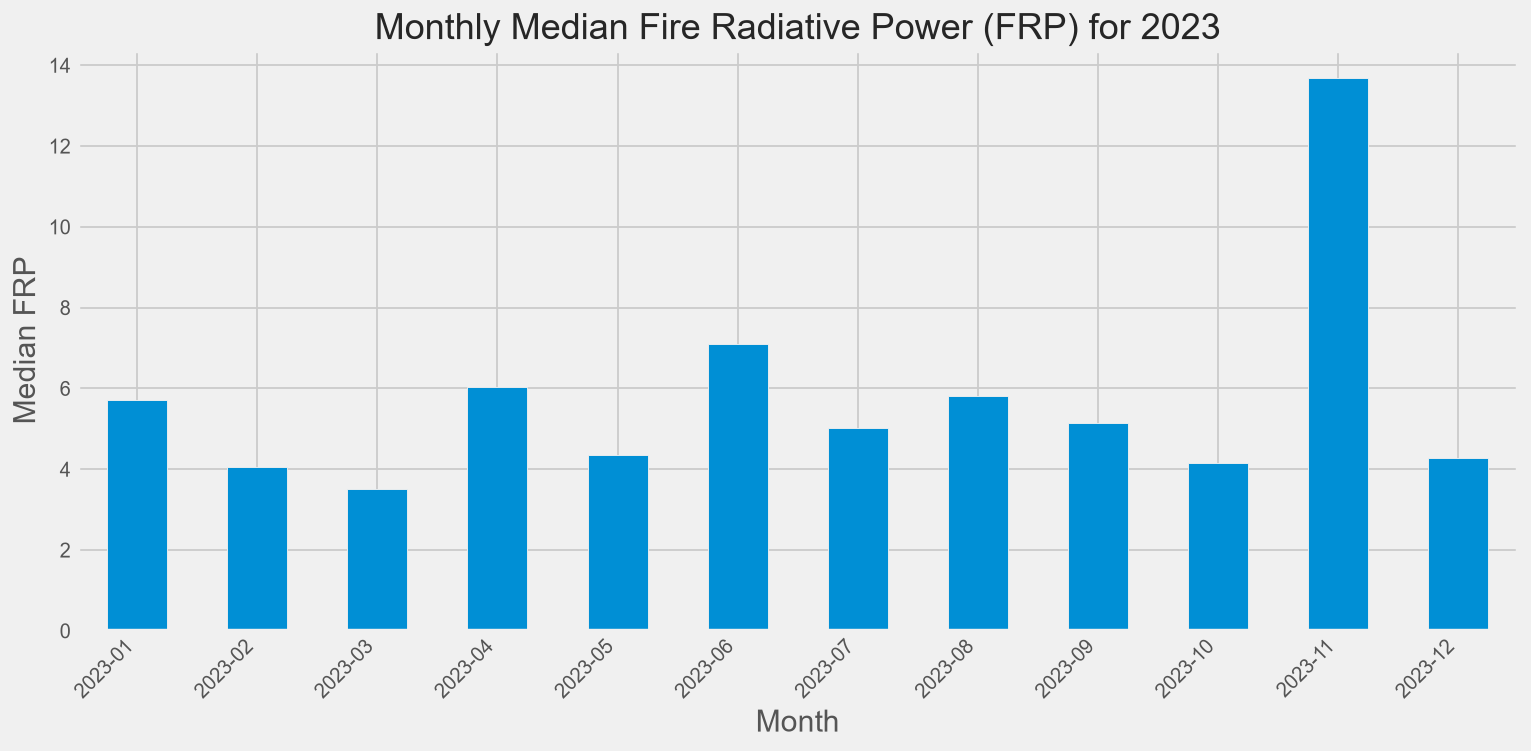

In [29]:
# TODO: Change year
year = 2023

 # Bar graph for the year
plot_frp_by_timeframe(df_españa, year)

In [30]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import branca.colormap as cm

def plot_intense_fires_folium(df, year, month=None):
    """
    Generates an interactive map showing the locations of intense fires (FRP >= 100)
    for a specific year and optional month using Folium, centered in Spain.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index and
                           'latitude', 'longitude', and 'frp' columns.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    if month is not None:
        df_filtered = df[(df.index.year == year) & (df.index.month == month)].copy()
        timeframe_str = f"Intense Fires for {month}/{year}"
    else:
        df_filtered = df[df.index.year == year].copy()
        timeframe_str = f"Intense Fires for {year}"

    # Filter for intense fires (FRP >= 100)
    intense_fires_df = df_filtered[df_filtered['frp'] >= 100].copy()

    if intense_fires_df.empty:
        print(f"No intense fires found for {timeframe_str} in Spain")
        return

    # --- CAMBIO AQUÍ: Coordenadas del centro de España y zoom adecuado ---
    m = folium.Map(location=[40.4167, -3.7037], zoom_start=6)

    # Add markers for intense fire locations
    max_frp = intense_fires_df['frp'].max()
    min_frp = intense_fires_df['frp'].min()

    # --- CAMBIO AQUÍ: Corrección para versiones modernas de Matplotlib ---
    cmap = plt.colormaps['YlOrRd'] 
    norm = mcolors.Normalize(vmin=min_frp, vmax=max_frp)

    for index, row in intense_fires_df.iterrows():
        # Scale FRP to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['frp'] - min_frp) / (max_frp - min_frp) * 13 if max_frp > min_frp else 5
        # Scale FRP to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['frp'] - min_frp) / (max_frp - min_frp) * 0.5 if max_frp > min_frp else 0.7

        # Get color from colormap based on FRP value
        color = mcolors.to_hex(cmap(norm(row['frp'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"FRP: {row['frp']:.2f}"
        ).add_to(m)

    # Add a legend adaptativa basada en los datos reales
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[min_frp, (min_frp + max_frp) / 2, max_frp],
        vmin=min_frp,
        vmax=max_frp
    )

    # Add the colormap as a legend to the map
    colormap.caption = f'Fire Radiative Power (FRP) - range: {min_frp:.0f} to {max_frp:.0f}'
    colormap.add_to(m)

    # Display the map
    display(m)

In [31]:
# TODO: Change year and month
year = 2024
month = 7

plot_intense_fires_folium(df_españa, year, month)

No intense fires found for Intense Fires for 7/2024 in Spain


In [32]:
m = folium.Map(location=[(min_latitude + max_latitude) / 2, (min_longitude + max_longitude) / 2], zoom_start=6)

folium.Rectangle(
    bounds=[(min_latitude, min_longitude), (max_latitude, max_longitude)],
    color='#ff7800',
    weight=2,
    fill=True,
    fill_color='#ffff00',
    fill_opacity=0.2
).add_to(m)

display(m)


In [33]:
# 1. Asegurar que el índice de df_filtered sea de tipo DatetimeIndex
if not isinstance(df_filtered.index, pd.DatetimeIndex):
    df_filtered.index = pd.to_datetime(df_filtered.index, errors='coerce')

# 2. Re-agrupar de forma diaria calculando la mediana en columnas numéricas
df_españa = df_filtered.resample('D').median(numeric_only=True)

# 3. Eliminar los valores nulos (días sin registros)
df_españa.dropna(how='all', inplace=True)

# 4. Mostrar los primeros resultados
print("=== Resumen Diario Generado Correctamente ===")
df_españa.head()

=== Resumen Diario Generado Correctamente ===


,latitude,longitude,brightness,scan,track,acq_time,bright_t31,frp,daynight,type
datetime,,,,,,,,,,
2020-01-01,41.313370,-4.232730,329.720,0.42,0.390,313.0,277.04,2.41,0.0,0.0
2020-01-02,41.526860,-1.905010,304.600,0.39,0.360,152.0,281.31,0.99,0.0,2.0
2020-01-03,43.236760,-5.736990,303.400,0.68,0.740,108.0,275.80,1.71,0.0,0.0
2020-01-04,38.096535,-0.838300,332.575,0.42,0.375,1250.0,294.67,2.48,0.0,1.0
2020-01-05,37.754675,-3.567375,302.975,0.42,0.380,207.0,286.82,1.05,0.0,2.0


Text(0, 0.5, 'FRP')

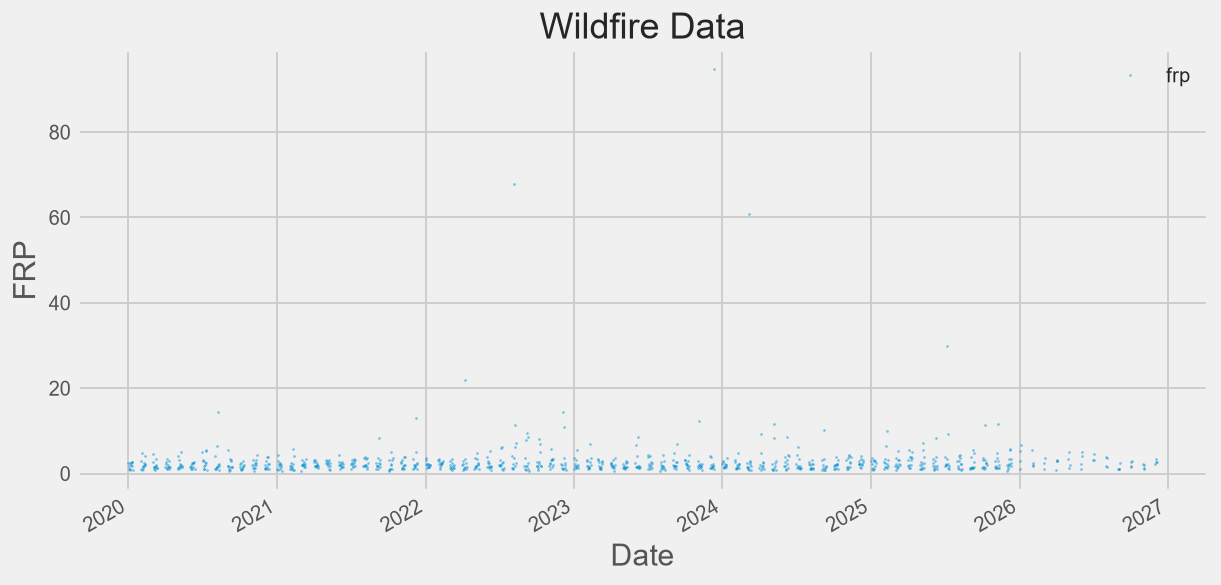

In [34]:
# Get the default seaborn color palette (list of colors to use in plots)
color_pal = sns.color_palette()

# Plot the 'frp' column from the DataFrame
df_españa.plot(
    style='.',                # Plot style: '.' means scatter-style points
    y='frp',                  # Column to plot on the y-axis
    figsize=(10, 5),          # Set the figure size (width=10, height=5)
    ms=1,                     # Marker size (small points since the dataset may be large)
    color=color_pal[0],       # Use the first color from the seaborn palette
    title='Wildfire Data',    # Title for the plot
    alpha=0.5                 # Set transparency (helps reduce overplotting)
)

# Label the x-axis and y-axis
plt.xlabel('Date')            # X-axis label: dates (time series)
plt.ylabel('FRP')             # Y-axis label: Fire Radiative Power

In [35]:
def create_features(df_españa):
    """
    Crea características de series temporales a partir del índice datetime 
    y las concatena al dataframe df_españa original.
    """
    df_españa = df_españa.copy()
    df_españa['date'] = df_españa.index
    df_españa['month'] = df_españa['date'].dt.month
    df_españa['weekofyear'] = df_españa['date'].dt.isocalendar().week.astype(int)
    df_españa['date_offset'] = (df_españa.date.dt.month * 100 + df_españa.date.dt.day - 320) % 1300

    # Clasificación de estaciones en español
    df_españa['season'] = pd.cut(df_españa['date_offset'], [0, 300, 602, 900, 1300],
                                 labels=['Primavera', 'Verano', 'Otoño', 'Invierno'],
                                 include_lowest=True)
    
    df_españa = df_españa.drop(columns=['date', 'date_offset']) # Elimina columnas temporales

    return df_españa

# Aplicación y separación de características (X) y variable objetivo (y)
df_features = create_features(df_españa)
X = df_features.drop(columns=['frp'])
y = df_features['frp']

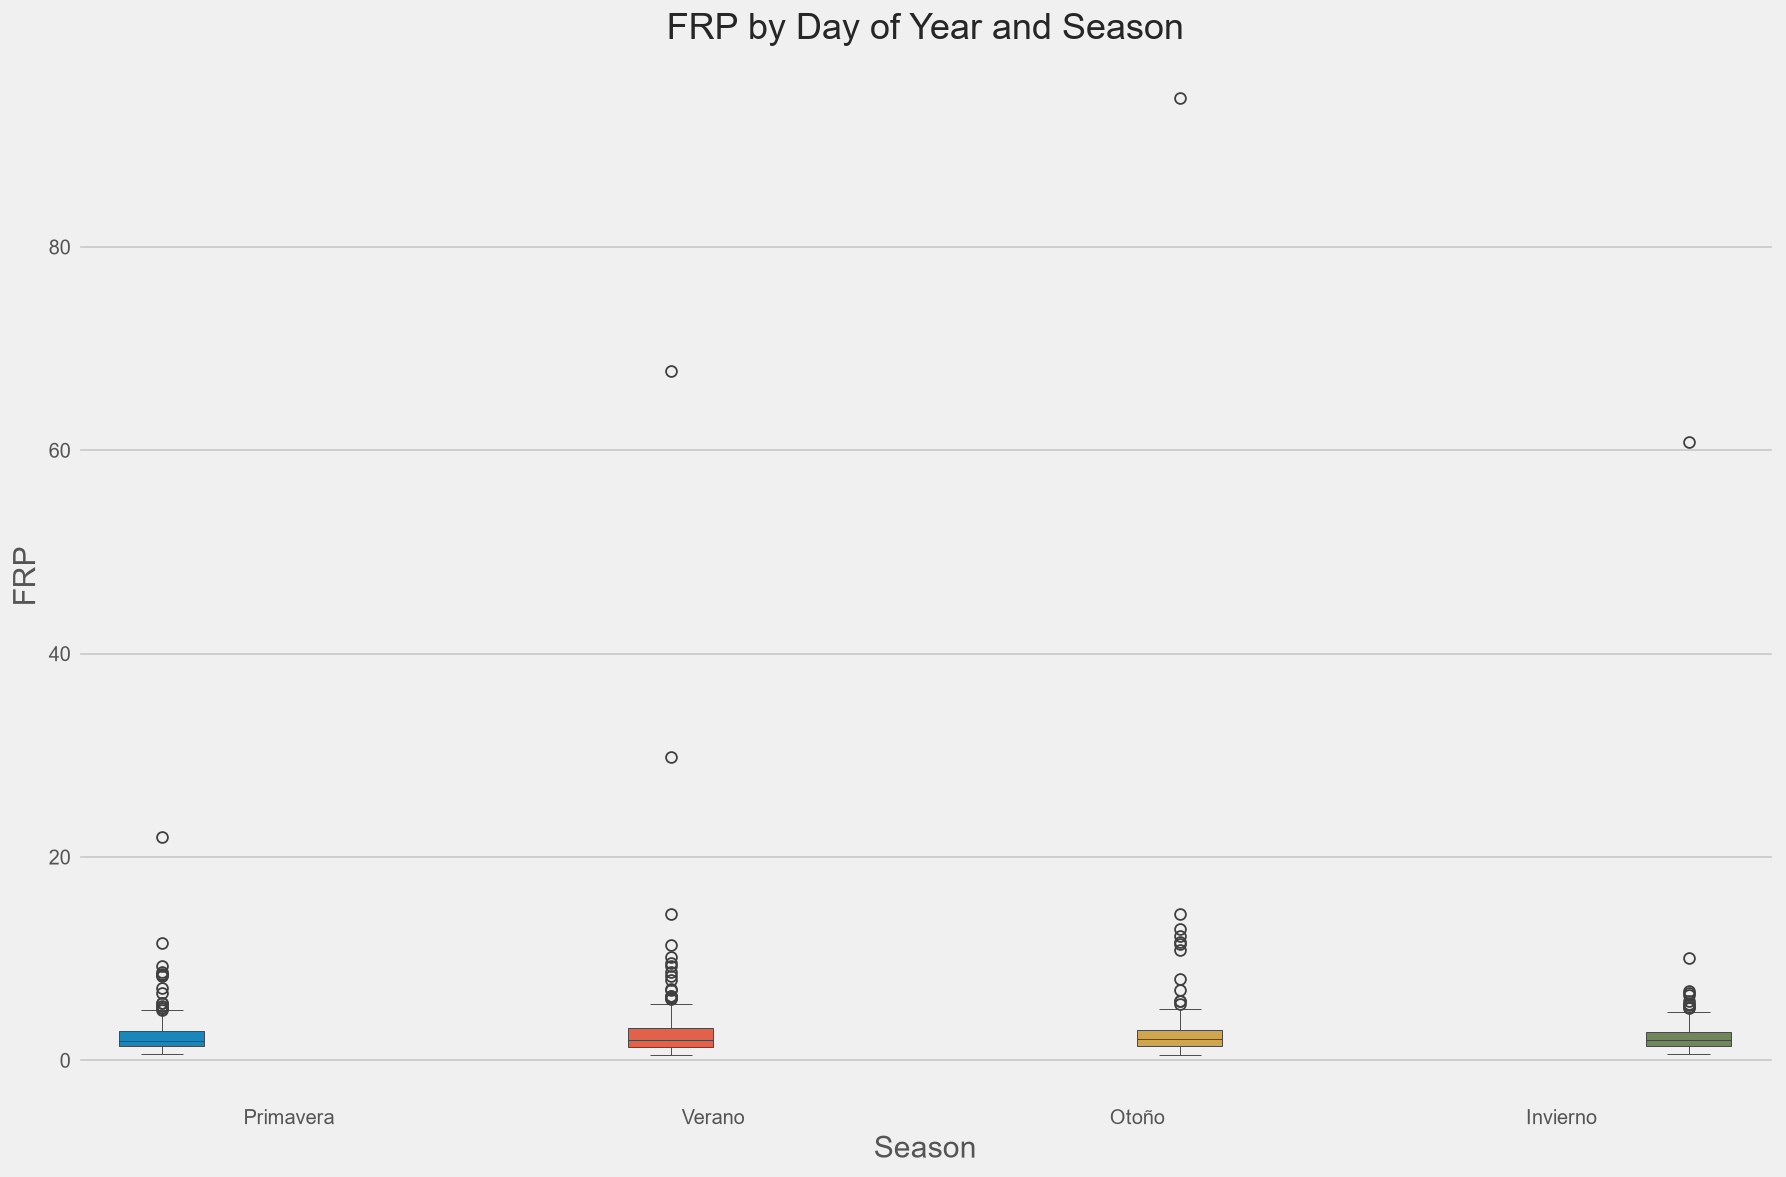

In [36]:
fig, ax = plt.subplots(figsize=(15, 10)) # Increased figure size
sns.boxplot(data=df_features.dropna(),
            x='season',
            y='frp',
            hue='season',
            ax=ax,
            linewidth=0.5) # Slightly reduced linewidth
ax.set_title('FRP by Day of Year and Season')
ax.set_xlabel('Season')
ax.set_ylabel('FRP')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

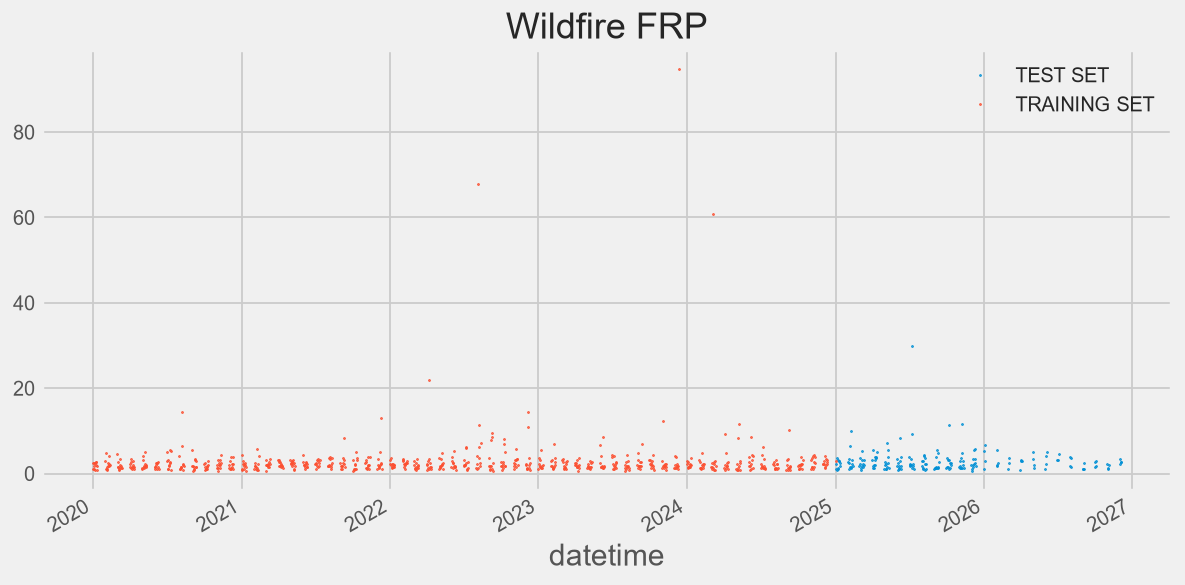

In [37]:
# TODO: Change date
split_date = '1-Jan-2025'
df_train = df_features.loc[df_features.index <= split_date].copy()
df_test = df_features.loc[df_features.index > split_date].copy()

# Plot train and test so you can see where we have split
pd.concat([df_test.groupby(df_test.index)['frp'].mean().rename('TEST SET'),
           df_train.groupby(df_train.index)['frp'].mean().rename('TRAINING SET')],
          axis=1) \
    .plot(figsize=(10, 5), title='Wildfire FRP', style='.', ms=1)
plt.show()

In [38]:
# Formatear los datos para el modelo Prophet de manera segura
df_train_prophet = df_train.reset_index()

# Renombramos dinámicamente la primera columna (el índice de fechas) a 'ds' y 'frp' a 'y'
df_train_prophet = df_train_prophet.rename(
    columns={
        df_train_prophet.columns[0]: 'ds',
        'frp': 'y'
    }
)

# Nos aseguramos de dejarle a Prophet SOLO las dos columnas que exige
df_train_prophet = df_train_prophet[['ds', 'y']]

# Limpieza rápida por si quedó algún valor vacío
df_train_prophet = df_train_prophet.dropna()

# Verificamos que los nombres hayan quedado perfectos
df_train_prophet.head()

,ds,y
0,2020-01-01,2.41
1,2020-01-02,0.99
2,2020-01-03,1.71
3,2020-01-04,2.48
4,2020-01-05,1.05


In [39]:
%%time
from prophet import Prophet

# Ahora sí, inicializar y entrenar con el formato correcto
model = Prophet()
model.fit(df_train_prophet)

10:18:35 - cmdstanpy - INFO - Chain [1] start processing
10:18:35 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 188 ms
Wall time: 3.22 s


In [40]:
# 1. Formateamos el conjunto de prueba (df_test) de forma dinámica y segura
df_test_prophet = df_test.reset_index()
# Renombramos la primera columna (el índice de fechas) a 'ds' sin importar cómo se llame
df_test_prophet = df_test_prophet.rename(
    columns={
        df_test_prophet.columns[0]: 'ds'
    }
)
# 2. Usamos el modelo Prophet ya entrenado para predecir sobre las fechas de prueba

df_test_fcst = model.predict(df_test_prophet)
# 3. Mostramos las columnas principales para verificar que todo funcionó con éxito
df_test_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2025-01-02,3.294112,-3.082148,9.765430
1,2025-01-03,2.697777,-3.769880,9.019020
2,2025-01-04,3.121124,-3.631876,9.289762
3,2025-01-05,1.701649,-5.014402,8.190848
4,2025-01-06,1.408201,-4.738566,7.721748


In [41]:
%%time
from prophet import Prophet

# 1. Inicializar y entrenar el modelo
model = Prophet()
model.fit(df_train_prophet)

# 2. Formatear el conjunto de prueba
df_test_prophet = df_test.reset_index()
df_test_prophet = df_test_prophet.rename(
    columns={
        df_test_prophet.columns[0]: 'ds'
    }
)

# 3. Predecir
df_test_fcst = model.predict(df_test_prophet)

# 4. Mostrar resultados
df_test_fcst[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

import os
import joblib

# Construir la ruta en tu directorio de trabajo actual
ruta_destino = os.path.join(os.getcwd(), 'prophet_model.pkl')

# Guardar
joblib.dump(model, ruta_destino)
print(f"✅ Modelo guardado en: {ruta_destino}")

10:18:35 - cmdstanpy - INFO - Chain [1] start processing
10:18:35 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo guardado en: c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\prophet_model.pkl
CPU times: total: 219 ms
Wall time: 384 ms


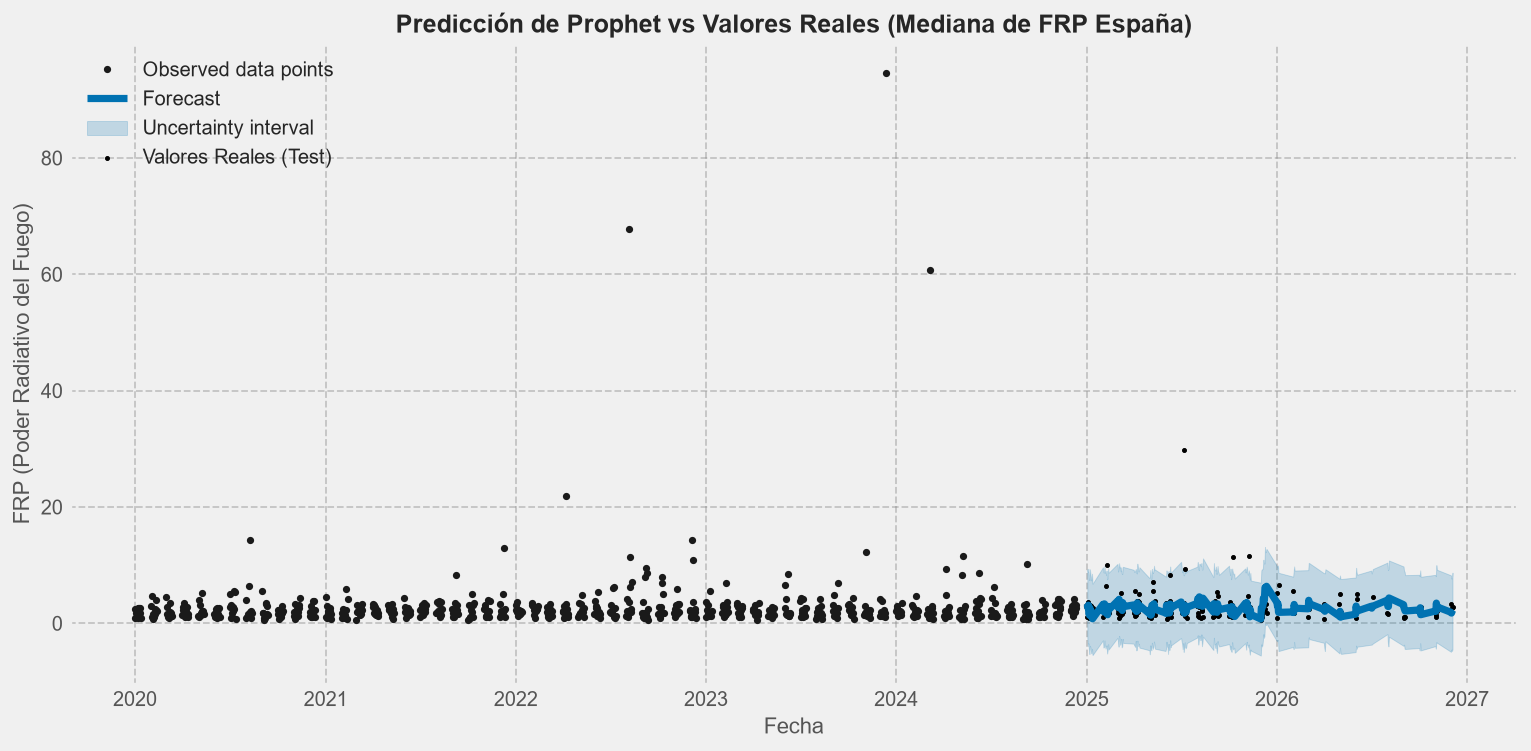

In [42]:
# 1. Crear la figura y el eje con el tamaño adecuado
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Graficar la predicción de Prophet en el eje creado
model.plot(df_test_fcst, ax=ax)

# 3. Superponer los valores reales usando el nombre correcto de tu columna ('frp')
ax.scatter(
    df_test_prophet['ds'], 
    df_test_prophet['frp'],  # <-- Cambiado 'y' por 'frp' para solucionar el KeyError
    color='black', 
    s=5, 
    label='Valores Reales (Test)'
)

# 4. Personalizar títulos y etiquetas en español
ax.set_title('Predicción de Prophet vs Valores Reales (Mediana de FRP España)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('FRP (Poder Radiativo del Fuego)', fontsize=12)

# 5. Forzar la activación de la leyenda para identificar los puntos reales e impedir duplicados
ax.legend(loc='upper left')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

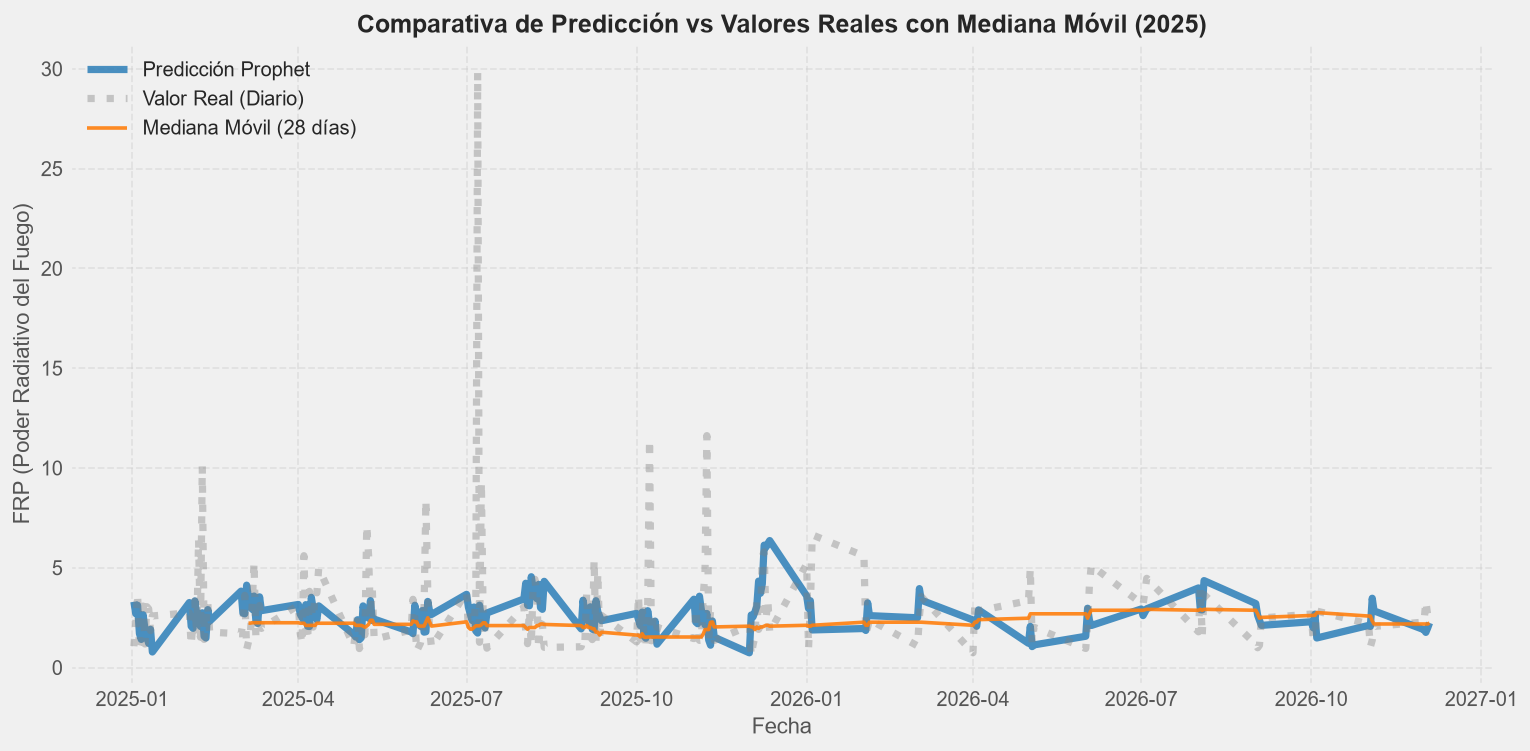

In [43]:
# 1. Crear la figura y el eje para graficar
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Graficar la predicción central de Prophet (yhat)
ax.plot(df_test_fcst['ds'], df_test_fcst['yhat'], label='Predicción Prophet', alpha=0.8, color='#1f77b4')

# 3. Graficar los valores reales usando la columna correcta ('frp')
ax.plot(df_test_prophet['ds'], df_test_prophet['frp'], label='Valor Real (Diario)', alpha=0.4, color='gray', linestyle=':')

# 4. Configurar la ventana móvil (puedes ajustar los días aquí, ej. 14 o 28 días)
rolling_window = 28

# Calcular y graficar la mediana móvil sobre la columna correcta ('frp')
df_test_prophet['rolling_avg'] = df_test_prophet['frp'].rolling(window=rolling_window).median()
ax.plot(
    df_test_prophet['ds'], 
    df_test_prophet['rolling_avg'], 
    label=f'Mediana Móvil ({rolling_window} días)', 
    alpha=0.9, 
    color='#ff7f0e', 
    linewidth=2
)

# 5. Personalización de títulos y etiquetas en español (Adaptado a 2025)
ax.set_title('Comparativa de Predicción vs Valores Reales con Mediana Móvil (2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('FRP (Poder Radiativo del Fuego)', fontsize=12)

# Activar la leyenda y cuadrícula para facilitar la lectura
ax.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [44]:
# Calculate MAE
mae = mean_absolute_error(df_test['frp'], df_test_fcst['yhat'])
print('MAE:', mae)

MAE: 1.5125007153988195


In [45]:
# Calculate MAPE
mean_absolute_percentage_error(df_test['frp'], df_test_fcst['yhat'])

np.float64(64.56628832354133)

In [46]:
def plot_prophet_predictions_folium(df_fcst, year, month=None):
    """
    Genera un mapa interactivo de España mostrando las ubicaciones de las predicciones de Prophet
    para un año y mes específicos usando Folium, escalando colores por el FRP predicho.

    Args:
        df_fcst (pd.DataFrame): DataFrame de predicciones de Prophet ('df_test_fcst').
        year (int): Año por el cual filtrar (ej. 2025).
        month (int, optional): Mes por el cual filtrar (1-12). Por defecto es None.
    """
    # Hacer una copia para no alterar el DataFrame original fuera de la función
    df_plot = df_fcst.copy()
    df_plot['ds'] = pd.to_datetime(df_plot['ds'])
    df_plot.set_index('ds', inplace=True)

    # Filtrar por año y mes
    if month is not None:
        df_filtered = df_plot[(df_plot.index.year == year) & (df_plot.index.month == month)].copy()
        timeframe_str = f"Predicciones de Prophet para {month}/{year} (España)"
    else:
        df_filtered = df_plot[df_plot.index.year == year].copy()
        timeframe_str = f"Predicciones de Prophet para {year} (España)"

    # Eliminar filas que no tengan coordenadas geográficas
    df_filtered.dropna(subset=['latitude', 'longitude'], inplace=True)

    if df_filtered.empty:
        print(f"No se encontraron predicciones con coordenadas para: {timeframe_str}")
        print("Asegúrate de que 'df_test_fcst' contenga las columnas 'latitude' y 'longitude'.")
        return

    # Centrar el mapa en la Península Ibérica, España
    m = folium.Map(location=[40.4167, -3.7037], zoom_start=6)

    # Obtener los límites reales de la predicción para normalizar los colores
    max_yhat = df_filtered['yhat'].max()
    min_yhat = df_filtered['yhat'].min()

    # Configurar paleta de colores (Amarillo -> Naranja -> Rojo) para incendios
    cmap = plt.colormaps['YlOrRd']
    norm = mcolors.Normalize(vmin=min_yhat, vmax=max_yhat)

    # Añadir marcadores circulares al mapa por cada registro
    for index, row in df_filtered.iterrows():
        # Escalar radio (entre 3 y 15) y opacidad (entre 0.4 y 0.9) según la intensidad del FRP
        if max_yhat > min_yhat:
            radius = 3 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 12
            opacity = 0.4 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 0.5
        else:
            radius = 6
            opacity = 0.7

        # Convertir el color a formato HEX para Folium
        color = mcolors.to_hex(cmap(norm(row['yhat'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"FRP Predicho: {row['yhat']:.2f}"
        ).add_to(m)

    # Crear una leyenda dinámica acorde a tus valores reales de FRP predichos
    col_legend = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        vmin=min_yhat,
        vmax=max_yhat
    )
    col_legend.caption = f'Poder Radiativo del Fuego (FRP) - {timeframe_str}'
    col_legend.add_to(m)

    # Desplegar el mapa interactivo
    display(m)

In [57]:
# 1. Forzar el año y mes correctos para tus datos de prueba (Abril de 2025)
year = 2025
month = 8

# 2. Verificar qué columnas tiene realmente df_test_prophet antes del merge
print("Columnas disponibles en df_test_prophet:", df_test_prophet.columns.tolist())

# 3. Si 'latitude' no está en df_test_prophet, la traemos de df_españa o df_filtered
if 'latitude' not in df_test_prophet.columns:
    # Creamos un parche rápido uniendo las coordenadas desde tu df_españa original usando la fecha
    df_coordenadas = df_españa[['latitude', 'longitude']].reset_index().rename(columns={df_españa.index.name or 'index': 'ds'})
    df_test_fcst_merged = df_test_fcst.merge(df_coordenadas, on='ds', how='left')
else:
    # Si ya existían, hacemos el merge normal
    df_test_fcst_merged = df_test_fcst.merge(df_test_prophet[['ds', 'latitude', 'longitude']], on='ds', how='left')

# 4. Ejecutar la función con los datos corregidos
plot_prophet_predictions_folium(df_test_fcst_merged, year, month)

Columnas disponibles en df_test_prophet: ['ds', 'latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_time', 'bright_t31', 'frp', 'daynight', 'type', 'month', 'weekofyear', 'season', 'rolling_avg']


In [ ]:
# 1. Mantener el año de tu conjunto de datos actual
year = 2024
# 2. Usar 'df_filtered' en lugar de df_españa para rescatar los picos de FRP reales
print("FRP Máximo en df_filtered:", df_filtered['frp'].max())

plot_intense_fires_folium(df_filtered, year)

FRP Máximo en df_filtered: 2313.87


In [63]:
import os

ruta_modelo = 'prophet_model.pkl'

# 1. Comprobamos el tamaño del archivo en bytes
tamano_bytes = os.path.getsize(ruta_modelo)
print(f"Tamaño del archivo: {tamano_bytes} bytes ({tamano_bytes / 1024:.2f} KB)")

# 2. Leemos los primeros caracteres para ver qué hay dentro
with open(ruta_modelo, 'r', encoding='utf-8', errors='ignore') as f:
    primeros_caracteres = f.read(200)

print("\n--- Primeros 200 caracteres del archivo ---")
print(primeros_caracteres)

Tamaño del archivo: 73185 bytes (71.47 KB)

--- Primeros 200 caracteres del archivo ---
      prophet.forecasterProphet)}(growthlinearchangepointspandasSeries)}(_mgrpandas.core.internals.managersSingleBlockManager)(]pandas.core.indexes.base
_new_IndexIndex}(datajoblib.n


In [64]:
# Importamos joblib, especialista en deserializar objetos numéricos y modelos de ML
import joblib

# Definimos la ruta de nuestro modelo
ruta_modelo = 'prophet_model.pkl'

# Cargamos el modelo. joblib detecta automáticamente el formato interno y compresión
modelo = joblib.load(ruta_modelo)

# Verificamos que el objeto cargado pertenece a la clase Prophet
print("¡Carga exitosa!")
print("Tipo del objeto:", type(modelo))

¡Carga exitosa!
Tipo del objeto: <class 'prophet.forecaster.Prophet'>


In [65]:
# Usamos dir() con una comprensión de listas para filtrar los atributos internos de Python (__...)
# Guardamos solo los nombres de atributos/métodos propios de Prophet
atributos_prophet = [attr for attr in dir(modelo) if not attr.startswith('__')]

# Imprimimos la lista completa de atributos disponibles para inspeccionarla a golpe de vista
print("Atributos y métodos encontrados dentro del modelo Prophet:")
print(atributos_prophet)

print("\n" + "="*50 + "\n")

# Vamos a comprobar la presencia de 5 atributos clave que nos dirán casi todo sobre el modelo:
# 1. 'history': El dataset con el que fue entrenado (si existe)
# 2. 'params': Los parámetros ajustados por el algoritmo
# 3. 'changepoints': Las fechas donde detectó cambios en la tendencia
# 4. 'seasonalities': Las estacionalidades configuradas (diaria, semanal, anual...)
# 5. 'extra_regressors': Regresores adicionales que se le hayan añadido

claves_clave = ['history', 'params', 'changepoints', 'seasonalities', 'extra_regressors']

for clave in claves_clave:
    # hasattr() comprueba si el objeto tiene ese atributo específico sin lanzar error si no existe
    if hasattr(modelo, clave):
        valor = getattr(modelo, clave)
        # Mostramos si el atributo está disponible y de qué tipo de dato se trata
        print(f" Atributo '{clave}': PRESENT - Tipo: {type(valor)}")
    else:
        print(f" Atributo '{clave}': NO PRESENT")

Atributos y métodos encontrados dentro del modelo Prophet:
['_load_stan_backend', '_logistic_uncertainty', '_make_historical_mat_time', '_make_trend_shift_matrix', '_sample_uncertainty', 'add_country_holidays', 'add_group_component', 'add_regressor', 'add_seasonality', 'calculate_initial_params', 'changepoint_prior_scale', 'changepoint_range', 'changepoints', 'changepoints_t', 'component_modes', 'construct_holiday_dataframe', 'country_holidays', 'daily_seasonality', 'extra_regressors', 'fit', 'fit_kwargs', 'flat_growth_init', 'flat_trend', 'fourier_series', 'growth', 'history', 'history_dates', 'holidays', 'holidays_mode', 'holidays_prior_scale', 'initialize_scales', 'interval_width', 'linear_growth_init', 'logistic_floor', 'logistic_growth_init', 'make_all_seasonality_features', 'make_future_dataframe', 'make_holiday_features', 'make_seasonality_features', 'mcmc_samples', 'n_changepoints', 'params', 'parse_seasonality_args', 'percentile', 'piecewise_linear', 'piecewise_logistic', 'plo

In [66]:
# Accedemos a la columna 'ds' dentro del DataFrame 'history' empaquetado en el modelo
fecha_inicio = modelo.history['ds'].min()
fecha_fin = modelo.history['ds'].max()

# Contamos la cantidad total de filas (registros/observaciones) del dataset de entrenamiento
num_observaciones = len(modelo.history)

# Extraemos el tipo de modelo de crecimiento/tendencia configurado ('linear', 'logistic', etc.)
tipo_crecimiento = modelo.growth

# Extraemos la serie de fechas donde el modelo identificó posibles cambios de tendencia
puntos_cambio = modelo.changepoints
num_changepoints = len(puntos_cambio)

# Imprimimos de forma estructurada toda la información extraída
print("===INFORMACIÓN DEL ENTRENAMIENTO DEL MODELO===")
print(f"Fecha de inicio del entrenamiento : {fecha_inicio}")
print(f"Fecha final del entrenamiento  : {fecha_fin}")
print(f"Número de observaciones (N)    : {num_observaciones}")
print(f"Tipo de tendencia (growth)      : {tipo_crecimiento}")
print(f"Número de changepoints activos  : {num_changepoints}")
print(f"Primer changepoint              : {puntos_cambio.min()}")
print(f"Último changepoint             : {puntos_cambio.max()}")

===INFORMACIÓN DEL ENTRENAMIENTO DEL MODELO===
Fecha de inicio del entrenamiento : 2020-01-01 00:00:00
Fecha final del entrenamiento  : 2025-01-01 00:00:00
Número de observaciones (N)    : 713
Tipo de tendencia (growth)      : linear
Número de changepoints activos  : 25
Primer changepoint              : 2020-02-12 00:00:00
Último changepoint             : 2023-12-11 00:00:00


In [67]:
# 1. Inspeccionamos las estacionalidades activas en el modelo
print("=== 1. ESTACIONALIDADES CONFIGURADAS ===")
# Recorremos el diccionario 'seasonalities' para ver el nombre y propiedades de cada ciclo
for nombre_estacionalidad, config in modelo.seasonalities.items():
    print(f"- {nombre_estacionalidad.upper()}:")
    print(f"   Período (días): {config['period']}")
    print(f"   Orden de Fourier: {config['fourier_order']}")
    print(f"   Modo: {config['mode']}")

print("\n" + "="*40 + "\n")

# 2. Inspeccionamos si el modelo requiere variables externas para predecir
print("=== 2. REGRESORES ADICIONALES (EXTRA REGRESSORS) ===")
regresores = list(modelo.extra_regressors.keys())
if regresores:
    print(f"El modelo UTILIZA regresores adicionales: {regresores}")
else:
    print("El modelo NO utiliza regresores adicionales. Es 100% autosuficiente en fechas.")

print("\n" + "="*40 + "\n")

# 3. Inspeccionamos los parámetros matemáticos internos optimizados por Stan
print("=== 3. PARÁMETROS INTERNOS OPTIMIZADOS (modelo.params) ===")
# Recorremos el diccionario de parámetros mostrando las formas (shapes) de las matrices de pesos
for nombre_param, matriz in modelo.params.items():
    print(f"- Parámetro '{nombre_param}': Forma {matriz.shape}")

=== 1. ESTACIONALIDADES CONFIGURADAS ===
- YEARLY:
   Período (días): 365.25
   Orden de Fourier: 10
   Modo: additive
- WEEKLY:
   Período (días): 7
   Orden de Fourier: 3
   Modo: additive


=== 2. REGRESORES ADICIONALES (EXTRA REGRESSORS) ===
El modelo NO utiliza regresores adicionales. Es 100% autosuficiente en fechas.


=== 3. PARÁMETROS INTERNOS OPTIMIZADOS (modelo.params) ===
- Parámetro 'lp__': Forma (1, 1)
- Parámetro 'k': Forma (1, 1)
- Parámetro 'm': Forma (1, 1)
- Parámetro 'delta': Forma (1, 25)
- Parámetro 'sigma_obs': Forma (1, 1)
- Parámetro 'beta': Forma (1, 26)
- Parámetro 'trend': Forma (1, 713)


In [68]:
# Definimos una función de auditoría para verificar la autonomía operativa del modelo
def auditar_autonomia_modelo(mod):
    # 1. Comprobamos si existen regresores exógenos configurados
    tiene_regresores = len(mod.extra_regressors) > 0
    
    # 2. Comprobamos si el historial interno 'history' está presente para el escalado temporal
    tiene_historial = (mod.history is not None) and (len(mod.history) > 0)
    
    print("=== RESULTADO DE LA AUDITORÍA DE AUTONOMÍA ===")
    
    if not tiene_regresores:
        print(" [OK] Autonomía de variables: El modelo NO requiere variables/columnas externas.")
    else:
        columnas_faltantes = list(mod.extra_regressors.keys())
        print(f" [ADVERTENCIA] Requiere datos externos futuros para las columnas: {columnas_faltantes}")
        
    if tiene_historial:
        print(" [OK] Autonomía temporal: Contiene 'history' e intervalos de referencia en memoria.")
    else:
        print(" [ADVERTENCIA] Falta 'history'. Se necesitarán las fechas límites originales para escalar 't'.")

    # Retornamos True solo si no necesita regresores y conserva su historial
    es_autonomo = (not tiene_regresores) and tiene_historial
    return es_autonomo

# Ejecutamos la función pasando nuestra instancia 'modelo'
modelo_listo = auditar_autonomia_modelo(modelo)

print("\n--------------------------------------------------")
print(f"¿Podemos predecir sin el CSV original?: {'SÍ, 100% AUTÓNOMO' if modelo_listo else 'NO, REQUIERE DATOS'}")
print("--------------------------------------------------")

=== RESULTADO DE LA AUDITORÍA DE AUTONOMÍA ===
 [OK] Autonomía de variables: El modelo NO requiere variables/columnas externas.
 [OK] Autonomía temporal: Contiene 'history' e intervalos de referencia en memoria.

--------------------------------------------------
¿Podemos predecir sin el CSV original?: SÍ, 100% AUTÓNOMO
--------------------------------------------------


In [69]:
# Definimos cuántos períodos hacia el futuro queremos proyectar (por ejemplo, 365 días / 1 año)
dias_a_predecir = 365

# Llamamos a make_future_dataframe() sobre la instancia del modelo.
# Le indicamos que genere 365 días futuros ('D'), incluyendo el historial previo (include_history=True)
df_futuro = modelo.make_future_dataframe(
    periods=dias_a_predecir, 
    freq='D', 
    include_history=True
)

# Imprimimos información sobre la estructura creada
print("=== ESTRUCTURA DEL DATAFRAME DE FECHAS FUTURAS ===")
print(f"Tipo de objeto devuelto : {type(df_futuro)}")
print(f"Dimensiones del DataFrame : {df_futuro.shape} (filas, columnas)")
print(f"Nombre de la columna     : {list(df_futuro.columns)}")

print("\n--- Transición entre el pasado y el futuro ---")
# Mostramos las filas donde termina el entrenamiento (alrededor de la fila 713) y comienzan las fechas futuras
print(df_futuro.iloc[710:718])

=== ESTRUCTURA DEL DATAFRAME DE FECHAS FUTURAS ===
Tipo de objeto devuelto : <class 'pandas.DataFrame'>
Dimensiones del DataFrame : (1078, 1) (filas, columnas)
Nombre de la columna     : ['ds']

--- Transición entre el pasado y el futuro ---
            ds
710 2024-12-11
711 2024-12-12
712 2025-01-01
713 2025-01-02
714 2025-01-03
715 2025-01-04
716 2025-01-05
717 2025-01-06


In [70]:
import pandas as pd

# 1. Ejecutamos predict() pasando el DataFrame de fechas futuras
# Esto calcula la tendencia, estacionalidades y límites para las 1078 fechas
forecast = modelo.predict(df_futuro)

# 2. Seleccionamos las columnas principales descritas en la teoría para construir nuestra tabla limpia
columnas_clave = [
    'ds', 'yhat', 'yhat_lower', 'yhat_upper', 
    'trend', 'yearly', 'weekly', 'additive_terms', 'multiplicative_terms'
]

df_predicciones = forecast[columnas_clave]

# 3. Filtramos únicamente las predicciones FUTURAS (posteriores a la fecha final de entrenamiento: 2025-01-01)
# Para mostrar una tabla representativa con los primeros 10 días del futuro
predicciones_futuras = df_predicciones[df_predicciones['ds'] > '2025-01-01'].head(10)

print("=== TABLA DE PREDICCIONES FUTURAS (PRIMEROS 10 DÍAS) ===")
# Configuramos pandas para que no recorte las columnas al imprimir por consola
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(predicciones_futuras.to_string(index=False))

=== TABLA DE PREDICCIONES FUTURAS (PRIMEROS 10 DÍAS) ===
        ds     yhat  yhat_lower  yhat_upper    trend    yearly    weekly  additive_terms  multiplicative_terms
2025-01-02 3.294112   -3.310187   10.042775 2.805647  0.500845 -0.012381        0.488464                   0.0
2025-01-03 2.697777   -3.296076    9.223609 2.805123  0.140211 -0.247557       -0.107346                   0.0
2025-01-04 3.121124   -3.086611    9.314756 2.804599 -0.189272  0.505797        0.316525                   0.0
2025-01-05 1.701649   -4.741108    8.016609 2.804075 -0.483388 -0.619037       -1.102425                   0.0
2025-01-06 1.408201   -4.493406    7.716968 2.803551 -0.738867 -0.656482       -1.395349                   0.0
2025-01-07 2.647817   -3.764716    8.887208 2.803026 -0.953428  0.798218       -0.155210                   0.0
2025-01-08 1.908144   -4.180830    8.674004 2.802502 -1.125800  0.231442       -0.894358                   0.0
2025-01-09 1.533879   -5.365372    7.606628 2.801978 -1

In [78]:
import pandas as pd

# 1. Identifica la última fecha de tus datos históricos reales
# (Sustituye esta fecha por la última que tengas en tu dataset original)
ultima_fecha_real = '2025-1-1' 

# 2. Filtra el dataframe 'forecast' para quedarte solo con fechas posteriores
prediccion_futura = forecast[forecast['ds'] > ultima_fecha_real]

# 3. Muestra las columnas más importantes (fecha, predicción, límite inferior y superior)
print(prediccion_futura[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

             ds      yhat  yhat_lower  yhat_upper
713  2025-01-02  3.294112   -3.310187   10.042775
714  2025-01-03  2.697777   -3.296076    9.223609
715  2025-01-04  3.121124   -3.086611    9.314756
716  2025-01-05  1.701649   -4.741108    8.016609
717  2025-01-06  1.408201   -4.493406    7.716968
...         ...       ...         ...         ...
1073 2025-12-28  4.671414   -1.770852   11.045797
1074 2025-12-29  4.208794   -2.202542   11.005397
1075 2025-12-30  5.235454   -0.830518   12.150403
1076 2025-12-31  4.245334   -2.053848   10.492769
1077 2026-01-01  3.590070   -2.997951    9.801173

[365 rows x 4 columns]


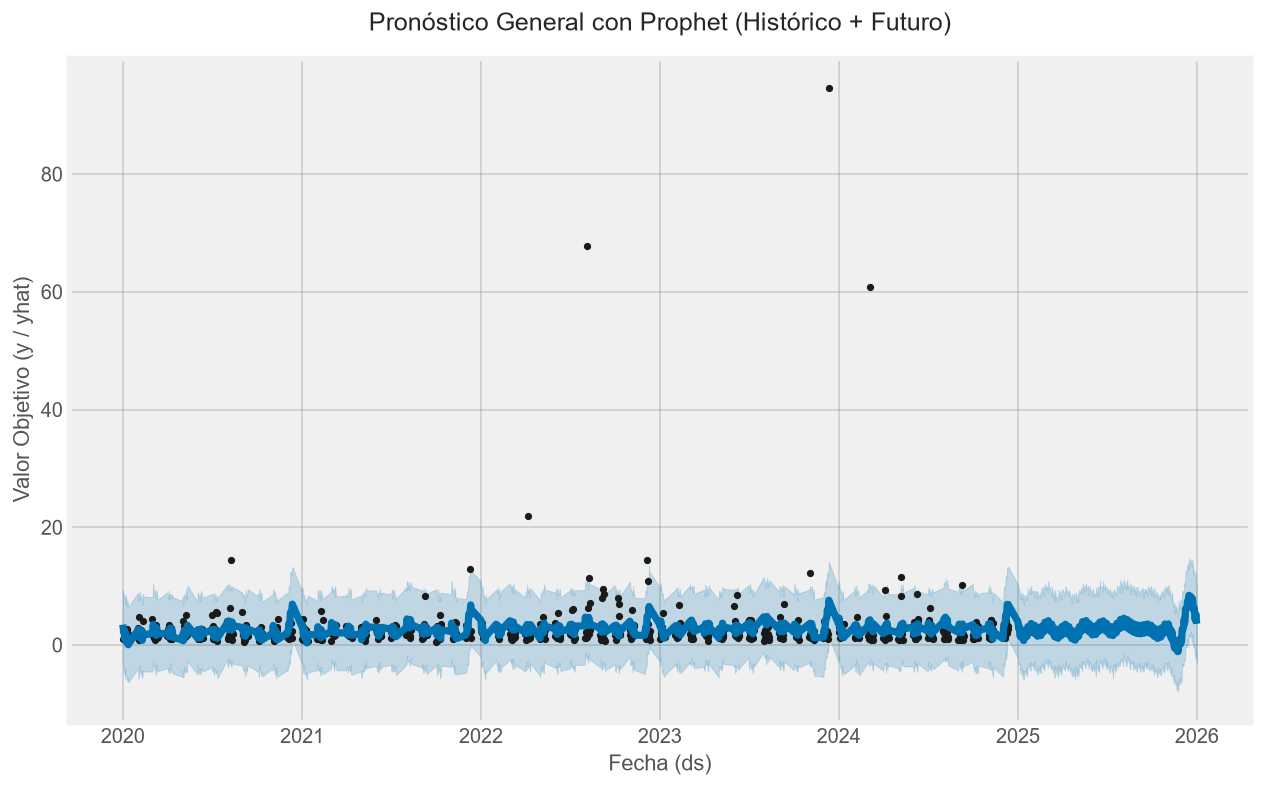

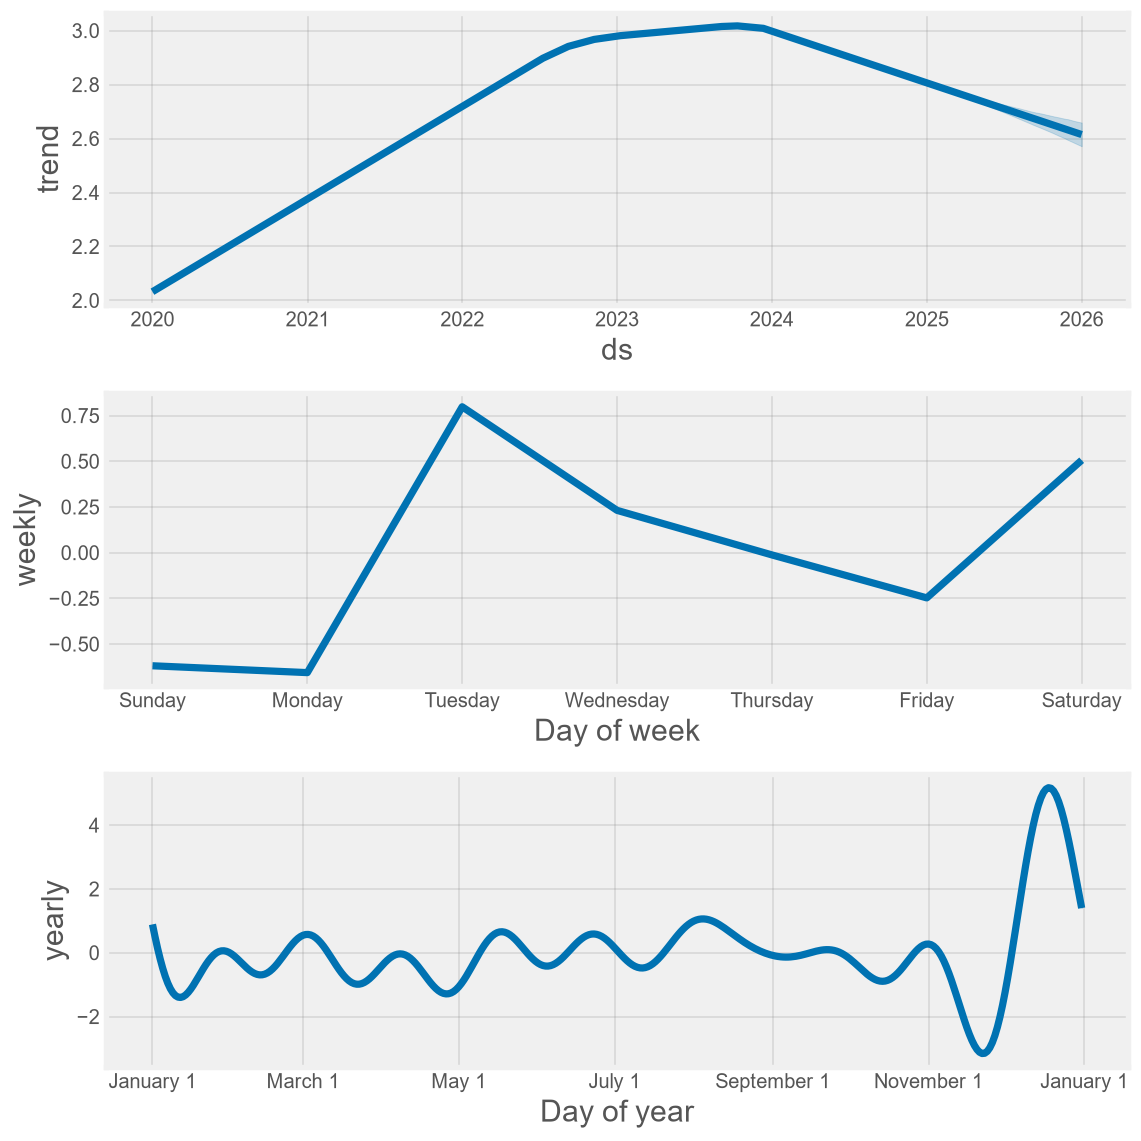

In [76]:
import matplotlib.pyplot as plt

# 1. Generamos la gráfica principal de pronóstico
# 'modelo.plot()' recibe el DataFrame de forecast y devuelve un objeto Figure de Matplotlib
fig_principal = modelo.plot(forecast)

# Personalizamos los títulos y ejes para mayor claridad
plt.title("Pronóstico General con Prophet (Histórico + Futuro)", fontsize=14, pad=15)
plt.xlabel("Fecha (ds)", fontsize=12)
plt.ylabel("Valor Objetivo (y / yhat)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50 + "\n")

# 2. Generamos la gráfica de descomposición de componentes
# 'modelo.plot_components()' desglosa la tendencia y las estacionalidades en paneles
fig_componentes = modelo.plot_components(forecast)
plt.show()

In [73]:
import joblib
import json
from prophet.serialize import model_to_json

# 1. EXPORTACIÓN DE PREDICCIONES A CSV
ruta_csv = 'predicciones_prophet.csv'

# Guardamos el DataFrame 'forecast' (o 'df_predicciones') en disco.
# 'index=False' evita escribir el número de fila en el archivo CSV.
# 'encoding='utf-8'' garantiza la compatibilidad de caracteres especiales.
forecast.to_csv(ruta_csv, index=False, encoding='utf-8')
print(f"[OK] Predicciones guardadas exitosamente en: '{ruta_csv}'")


# 2. GUARDAR MODELO CON JOBLIB (.pkl)
ruta_pkl = 'prophet_model_backup.pkl'

# Guardamos la instancia completa del modelo usando joblib
joblib.dump(modelo, ruta_pkl)
print(f"[OK] Copia del modelo guardada con joblib en: '{ruta_pkl}'")


# 3. GUARDAR MODELO EN FORMATO OFICIAL PROPHET (.json)
ruta_json = 'prophet_model.json'

# Abrimos el archivo en modo escritura de texto ('w')
with open(ruta_json, 'w', encoding='utf-8') as f:
    # 'model_to_json()' convierte la estructura interna del modelo en una cadena de texto JSON
    # 'json.dump()' escribe esa cadena directamente en el archivo
    json.dump(model_to_json(modelo), f)

print(f"[OK] Modelo exportado en formato JSON oficial en: '{ruta_json}'")

[OK] Predicciones guardadas exitosamente en: 'predicciones_prophet.csv'
[OK] Copia del modelo guardada con joblib en: 'prophet_model_backup.pkl'
[OK] Modelo exportado en formato JSON oficial en: 'prophet_model.json'


In [74]:
import os

archivos_esperados = ['predicciones_prophet.csv', 'prophet_model_backup.pkl', 'prophet_model.json']

print("=== VERIFICACIÓN DE ARCHIVOS GENERADOS ===")
for archivo in archivos_esperados:
    if os.path.exists(archivo):
        tamano_kb = os.path.getsize(archivo) / 1024
        print(f" [EXISTE] {archivo:<27} | Tamaño: {tamano_kb:.2f} KB")
    else:
        print(f" [FALTA]  {archivo}")

=== VERIFICACIÓN DE ARCHIVOS GENERADOS ===
 [EXISTE] predicciones_prophet.csv    | Tamaño: 331.09 KB
 [EXISTE] prophet_model_backup.pkl    | Tamaño: 71.50 KB
 [EXISTE] prophet_model.json          | Tamaño: 131.86 KB


## **7. Reporte de Análisis Exploratorio de Datos (EDA)**

### **Dataset:** Alertas de Anomalías Térmicas (MODIS 2024)



---

## 1. Resumen Ejecutivo

El conjunto de datos analizado corresponde a las detecciones de anomalías térmicas (focos de calor e incendios) capturadas por el instrumento **MODIS** a bordo de los satélites **Terra** y **Aqua** durante el año **2024**. El conjunto de datos original consolida información de múltiples países con un total de **308,402 registros** y 16 variables iniciales. Tras un proceso riguroso de limpieza, normalización y filtrado de ruido, el dataset quedó optimizado para el análisis.

---

## 2. Calidad de los Datos y Proceso de Limpieza

### **Diagnóstico Inicial**

* **Volumen:** 308,402 filas y 16 columnas.


* **Integridad:** El dataset inicial presentó una **calidad excepcional en términos de completitud, registrando un 0% de valores nulos** en todas sus variables.



### **Transformaciones y Optimizaciones Aplicadas**

1. **Formateo de Tiempo:** Se convirtieron las variables de adquisición (`acq_date` y `acq_time`) y se consolidaron en una única variable de tipo fecha-hora (`acq_datetime`) para permitir análisis de series temporales precisos.


2. **Validación Geográfica:** Se validó que el 100% de las coordenadas estuvieran en los rangos lógicos (Latitud: $-90$ a $90$; Longitud: $-180$ a $180$).


3. **Optimización de Memoria:** Variables con alta repetitividad (`satellite`, `instrument`, `daynight`, `pais`, `type`) fueron transformadas al tipo de dato `category`. Las variables numéricas de temperatura y potencia (`brightness`, `bright_t31`, `frp`) se redondearon a dos decimales, reduciendo el uso de memoria a **49.1 MB**.


4. **Mapeo de Negocio:** La columna categórica `type` fue decodificada desde sus valores numéricos originales a etiquetas legibles:


* **0:** Incendio forestal/vegetación


* **1:** Volcán


* **2:** Industria/Foco estático


* **3:** Otros/Fuera de rango





---

## 3. Análisis Descriptivo e Interpretación de Variables

### **Distribución de Tipos de Focos Térmicos**

Una vez aplicado el mapeo, se observa la siguiente distribución en el dataset:

| Tipo de Foco Térmico | Cantidad de Alertas | Porcentaje |
| --- | --- | --- |
| **Incendio forestal/vegetación** | 279,748 | 90.71% |
| **Industria/Foco estático** | 26,770 | 8.68% |
| **Volcán** | 1,760 | 0.57% |
| **Otros/Fuera de rango** | 124 | 0.04% |

> 📌 **Interpretación:** Más del **90% de las alertas** corresponden a incendios forestales o de vegetación. Esto demuestra que el dataset está masivamente orientado al monitoreo ambiental y de emergencias por fuego, dejando las actividades industriales y volcánicas como eventos secundarios o ruido de fondo controlado.
> 
> 

### **Análisis de la Confianza (Filtro de Ruido)**

La variable `confidence` (0-100%) mide la certidumbre del algoritmo de MODIS sobre si el píxel detectado representa un fuego real.

* **Media original:** 66.09%.


* **Mediana (Percentil 50):** 69.00%.



El EDA propone una estrategia de **limpieza de ruido** eliminando las alertas con confianza baja ($< 50\%$).

* **Registros útiles (Confianza $\ge 50\%$):** 231,964 alertas.


* **Ruido/Falsos positivos eliminados:** 76,438 alertas (24.78% del total).



> 📌 **Interpretación:** Uno de cada cuatro registros originales de MODIS es potencialmente un falso positivo o una medición de baja fiabilidad. Para el entrenamiento de modelos predictivos o análisis de riesgo sectorial, **es mandatorio trabajar con el subset filtrado de 231,964 alertas** para asegurar la precisión de las conclusiones.
> 
> 